# Modèle Causal — Évaluation des domestiques en cyclisme
## Double Machine Learning + Causal Forest (2018–2025) — Team Visma | Lease a Bike (Jumbo-Visma)

**Objectif :** Estimer l'effet **causal** de la sélection d'un coureur (`selected`) sur la performance de l'équipe (`pts_uci_equipe_stage`), en corrigeant le biais de sélection historique.

---
**Cadre causal (DAG) :**
```
Race Characteristics (X)  ──→  selected (T)  ──→  pts_uci_equipe_stage (Y)
 + forme_equipe                                              ↑
 + startlist_quality                                         │
 + leader_played           ──────────────────────────────────┘
 + avg_temperature
```
L'effet d'intérêt est **T → Y** (flèche rouge dans le OnePager).

---
**Structure :**
1. Imports & Configuration
2. Chargement & préparation des données
3. Pourquoi le ML classique échoue — illustration
4. Double Machine Learning (DML) — ATE par coureur
   - 4.5 Analyse détaillée — toutes les variables
   - 4.6 Analyse du leader & contexte d'équipe
   - 4.7 Niveau de compétition (startlist_quality)
5. Causal Forest — CATE hétérogène
   - 5.5 **Hétérogénéité apprise : opportunités manquées & sélections sub-optimales**
6. Validation & tests de robustesse
7. Application — recommandation de calendrier

## 1. Imports & Configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Configuration ───────────────────────────────────────────────────────────
RIDER_DIR  = Path('rider_data')
OUTCOME    = 'pts_uci_equipe_stage'
TREATMENT  = 'selected'
N_FOLDS    = 5
N_BOOT     = 500
N_TREES    = 500
RANDOM_STATE = 42

# ── Features confondantes X ─────────────────────────────────────────────────
FEATURES_RACE = [
    'distance_gpx_km', 'denivele_pos', 'denivele_neg',
    'altitude_max', 'altitude_min',
    'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
    'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
    'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
    'cobblestones_km', 'compacted_gravel_km',
    'cobblestones_last_10km', 'compacted_gravel_last_10km',
    'startlist_quality',   # niveau de compétition PCS — 1.2% NaN
]
FEATURES_DYNAMIC = [
    'forme_equipe',   # rolling 5 courses par équipe×cluster — 3.8% NaN  (imputation médiane)
    'n_races_30d',
    'km_30d',
    'leader_played',  # réactivé — 2024-2025 comblés via team_leaders.csv
    # avg_temperature : EXCLU — 99% NaN avant 2022 (trop sparse)
]
FEATURES_CLUSTER = ['stage_cluster']
ALL_FEATURES = FEATURES_RACE + FEATURES_DYNAMIC + FEATURES_CLUSTER

# ── Colonnes pour l'affichage détaillé ──────────────────────────────────────
COLS_RACE_ALL = [
    'distance_gpx_km', 'cobblestones_km', 'compacted_gravel_km',
    'denivele_pos', 'denivele_neg', 'altitude_max', 'altitude_min',
    'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'loc_last_col_cat4', 'loc_last_col_cat3', 'loc_last_col_cat2',
    'loc_last_col_cat1', 'loc_last_col_hc',
    'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
    'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
    'cobblestones_last_50km', 'compacted_gravel_last_50km',
    'cobblestones_last_20km', 'compacted_gravel_last_20km',
    'cobblestones_last_10km', 'compacted_gravel_last_10km',
]
COLS_DYNAMIC_ALL = [
    'forme_equipe', 'n_races_30d', 'km_30d', 'leader_played',
    'max_pts', 'startlist_quality', 'avg_temperature',
]
COLS_OUTCOME_ALL = [
    'pts_uci', 'pts_uci_equipe_stage', 'pts_uci_equipe_total',
    'pts_uci_gc', 'pts_uci_kom', 'pts_uci_points',
    'rang', 'rang_gc_final', 'pts_uci_gc_final', 'pts_ratio',
]

# ── Palette couleurs ─────────────────────────────────────────────────────────
C_BLUE   = '#2271B3'   # sélectionné / positif / primary
C_ORANGE = '#E8824B'   # non sélectionné / secondary
C_RED    = '#D94F3D'   # négatif / sub-optimal
C_GRAY   = '#BDBDBD'   # non significatif
C_TEAL   = '#3BAAAA'   # cluster sprint
C_PURPLE = '#8B5EA6'   # cluster haute montagne
CLUSTER_COLORS = {
    '⏱️  CLM':            '#5B5B9B',
    '🟢  Plat/Sprint':    C_TEAL,
    '⛰️  Moy. montagne':  C_ORANGE,
    '🏔️  Haute montagne': C_PURPLE,
}

print('✅ Configuration chargée')
print(f'   Outcome (Y)           : {OUTCOME}')
print(f'   Traitement (T)        : {TREATMENT}')
print(f'   Features race         : {len(FEATURES_RACE)}  (incl. startlist_quality)')
print(f'   Features dynamiques   : {len(FEATURES_DYNAMIC)}  (leader_played/avg_temperature exclus)')
print(f'   Total features X      : {len(ALL_FEATURES)}')


/Users/arthurdeletang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Configuration chargée
   Outcome (Y)           : pts_uci_equipe_stage
   Traitement (T)        : selected
   Features race         : 24  (incl. startlist_quality)
   Features dynamiques   : 4  (leader_played/avg_temperature exclus)
   Total features X      : 29


## 2. Chargement & préparation des données

### Fonction `load_rider`
Charge les données d'un coureur depuis `rider_data/`. Les données sont déjà enrichies (plus de join nécessaire avec `race_features.csv` — tout est déjà dans chaque fichier).

On peut aussi charger tous les coureurs d'une équipe pour faire une analyse d'équipe.

In [2]:
LEADER_PLAYED_LOOKUP = {}  # populated by the next cell

def load_rider(rider_name, annee=None, equipe=None):
    """
    Charge le fichier d'un coureur depuis rider_data/.
    equipe : str ou liste de str.
    """
    path = RIDER_DIR / f'{rider_name}.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path, low_memory=False)
    df['date']      = pd.to_datetime(df['date'], errors='coerce')
    df['stage_num'] = pd.to_numeric(df['stage_num'], errors='coerce')
    df['rider']     = rider_name
    if annee:
        df = df[df['year'] == annee]
    if equipe is not None:
        equipe_list = equipe if isinstance(equipe, list) else [equipe]
        df = df[df['equipe'].isin(equipe_list)]
    # Fill missing leader_played for 2024-2025 from team_leaders lookup
    if 'leader_played' in df.columns and LEADER_PLAYED_LOOKUP:
        mask_nan = df['leader_played'].isna()
        if mask_nan.any():
            keys = list(zip(
                df.loc[mask_nan, 'equipe'],
                df.loc[mask_nan, 'year'].astype(int),
                df.loc[mask_nan, 'course'],
                df.loc[mask_nan, 'stage_num'],
            ))
            df.loc[mask_nan, 'leader_played'] = [LEADER_PLAYED_LOOKUP.get(k, 0) for k in keys]
    return df if len(df) > 0 else None


def find_team_riders(equipe, annee=None):
    """
    Trouve tous les coureurs ayant roulé pour une équipe (str ou liste).
    annee=None → toutes les années.
    """
    equipe_list = equipe if isinstance(equipe, list) else [equipe]
    riders = []
    for f in sorted(RIDER_DIR.glob('*.csv')):
        try:
            df = pd.read_csv(f, usecols=['year','equipe'], low_memory=False)
            mask = df['equipe'].isin(equipe_list)
            if annee is not None:
                mask = mask & (df['year'] == annee)
            if mask.any():
                riders.append(f.stem)
        except Exception:
            pass
    return riders


def prepare_features(df, features=None):
    """
    Prépare les matrices X, T, Y pour le DML/Causal Forest.
    Retourne X, T, Y, df_clean, feature_names.

    Gère automatiquement les nouvelles colonnes :
    startlist_quality, leader_played, avg_temperature (NaN → médiane).
    """
    if features is None:
        features = ALL_FEATURES

    df = df.copy()
    feats = [f for f in features if f in df.columns]

    df[OUTCOME]   = pd.to_numeric(df[OUTCOME],   errors='coerce')
    df[TREATMENT] = pd.to_numeric(df[TREATMENT], errors='coerce')

    # On exige seulement les colonnes race de base (hors nouvelles features PCS)
    essential = [f for f in FEATURES_RACE
                 if f in df.columns and f not in ('startlist_quality',)]
    df_clean = df.dropna(subset=essential + [OUTCOME, TREATMENT]).reset_index(drop=True)

    if len(df_clean) < 20:
        return None

    # Imputation médiane pour toutes les features (y compris nouvelles)
    for col in feats:
        if col in df_clean.columns and df_clean[col].isna().any():
            med = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(med if not pd.isna(med) else 0)

    X = df_clean[feats].values.astype(float)
    T = df_clean[TREATMENT].values.astype(float)
    Y = np.log1p(np.clip(df_clean[OUTCOME].values.astype(float), 0, None))

    return X, T, Y, df_clean, feats


print('✅ Fonctions chargées')
print(f'Fichiers disponibles : {len(list(RIDER_DIR.glob("*.csv")))} coureurs')

✅ Fonctions chargées
Fichiers disponibles : 5137 coureurs


In [3]:
# ── Reconstruction leader_played 2024-2025 via team_leaders.csv ─────────────
# Résultat mis en cache dans leader_played_lookup.parquet pour éviter
# de rescanner tous les fichiers rider à chaque lancement.

_TEAM_NAME_MAP = {
    'Team Visma | Lease a Bike': 'Team Visma',
    'Team Visma | Lease a Bike Development': 'Jumbo-Visma Development Team',
}
_LOOKUP_CACHE = Path('leader_played_lookup.parquet')

def _build_leader_played_lookup(rider_dir=RIDER_DIR, years=(2024, 2025)):
    if _LOOKUP_CACHE.exists():
        df_cache = pd.read_parquet(_LOOKUP_CACHE)
        lookup = {
            (row.equipe, int(row.year), row.course, row.stage_num): int(row.is_leader)
            for row in df_cache.itertuples()
        }
        print(f'leader_played lookup chargé depuis cache : {len(lookup)} entrées')
        return lookup

    tl_path = Path('team_leaders.csv')
    if not tl_path.exists():
        print('team_leaders.csv introuvable — leader_played non rempli pour 2024-2025')
        return {}
    tl = pd.read_csv(tl_path)[['team', 'year', 'leader_1_rider']]

    rows = []
    for f in sorted(rider_dir.glob('*.csv')):
        try:
            df = pd.read_csv(
                f, usecols=['year', 'equipe', 'course', 'stage_num', 'selected'],
                low_memory=False,
            )
            df = df[df['year'].isin(years) & (df['selected'] == 1)].copy()
            if len(df):
                df['rider'] = f.stem
                rows.append(df)
        except Exception:
            pass

    if not rows:
        return {}

    selected = pd.concat(rows, ignore_index=True)
    selected['team_key'] = selected['equipe'].map(_TEAM_NAME_MAP).fillna(selected['equipe'])
    selected = selected.merge(tl, left_on=['team_key', 'year'], right_on=['team', 'year'], how='left')
    selected['is_leader'] = (selected['rider'] == selected['leader_1_rider']).astype(int)

    leader_present = (
        selected.groupby(['equipe', 'year', 'course', 'stage_num'])['is_leader']
        .max()
        .reset_index()
    )
    leader_present['year'] = leader_present['year'].astype(int)
    leader_present.to_parquet(_LOOKUP_CACHE, index=False)

    lookup = {
        (row.equipe, int(row.year), row.course, row.stage_num): int(row.is_leader)
        for row in leader_present.itertuples()
    }
    print(f'leader_played lookup construit et mis en cache : {len(lookup)} entrées')
    return lookup

LEADER_PLAYED_LOOKUP = _build_leader_played_lookup()


leader_played lookup chargé depuis cache : 25275 entrées


In [4]:
# ── Configurer l'équipe cible ────────────────────────────────────────────────
VISMA_TEAMS = [
    'Team LottoNL-Jumbo',
    'Jumbo-Visma',
    'Team Jumbo-Visma',
    'Team Visma | Lease a Bike',
]
EQUIPE         = VISMA_TEAMS
EQUIPE_LABEL   = 'Team Visma | Lease a Bike (Jumbo-Visma)'
ANNEE          = None
MIN_SELECTIONS = 20   # filtre : au moins N sélections dans l'équipe

print(f'Recherche — {EQUIPE_LABEL} | Année: {ANNEE or "toutes"}')
all_riders = find_team_riders(EQUIPE, ANNEE)
print(f'→ {len(all_riders)} coureurs trouvés au total')

RIDERS   = []
excluded = []
for rn in all_riders:
    df_r = load_rider(rn, equipe=EQUIPE)
    if df_r is None:
        continue
    n_sel = int((df_r[TREATMENT] == 1).sum())
    if n_sel >= MIN_SELECTIONS:
        RIDERS.append(rn)
    else:
        excluded.append((rn, n_sel))

print(f'→ {len(RIDERS)} coureurs conservés (≥ {MIN_SELECTIONS} sélections)')
print(f'→ {len(excluded)} coureurs exclus   (< {MIN_SELECTIONS} sélections)')
if excluded:
    excl_s = sorted(excluded, key=lambda x: x[1], reverse=True)
    print('   Exclus :', ', '.join(f"{r} ({n})" for r, n in excl_s[:10]),
          '...' if len(excl_s) > 10 else '')
print()
print('Coureurs conservés :')
print(RIDERS)


Recherche — Team Visma | Lease a Bike (Jumbo-Visma) | Année: toutes
→ 93 coureurs trouvés au total
→ 79 coureurs conservés (≥ 20 sélections)
→ 14 coureurs exclus   (< 20 sélections)
   Exclus : fisher-black_finn (18), nørtoft_morten_aalling (14), uglehus_mikal_grimstad (13), maas_jan (12), rex_tim (12), smith_william (11), smithson_jed (11), belletta_dario_igor (10), ryan_archie (10), høydahl_jonas_kind (8) ...

Coureurs conservés :
['affini_edoardo', 'battaglin_enrico', 'behrens_niklas', 'bennett_george', 'benoot_tiesj', 'boom_lars', 'bouwman_koen', 'boven_lars', 'brennan_matthew', 'campenaerts_victor', 'clement_stef', 'de_plus_laurens', 'de_tier_floris', 'dekker_david', 'dennis_rohan', 'dumoulin_tom', 'eenkhoorn_pascal', 'foss_tobias', 'geleijn_owen', 'gesink_robert', 'gloag_thomas', 'graat_tijmen', 'groenewegen_dylan', 'hagenes_per_strand', 'harper_chris', 'hessmann_michel', 'hofstede_lennard', 'huising_menno', 'jansen_amund_grøndahl', 'jorgenson_matteo', 'kelderman_wilco', 'kooij_o

## 3. Pourquoi le ML classique échoue — Illustration

On montre ici concrètement pourquoi une régression naïve `Y ~ T + X` ou une comparaison brute `E[Y|T=1] - E[Y|T=0]` est biaisée, sur un coureur exemple.

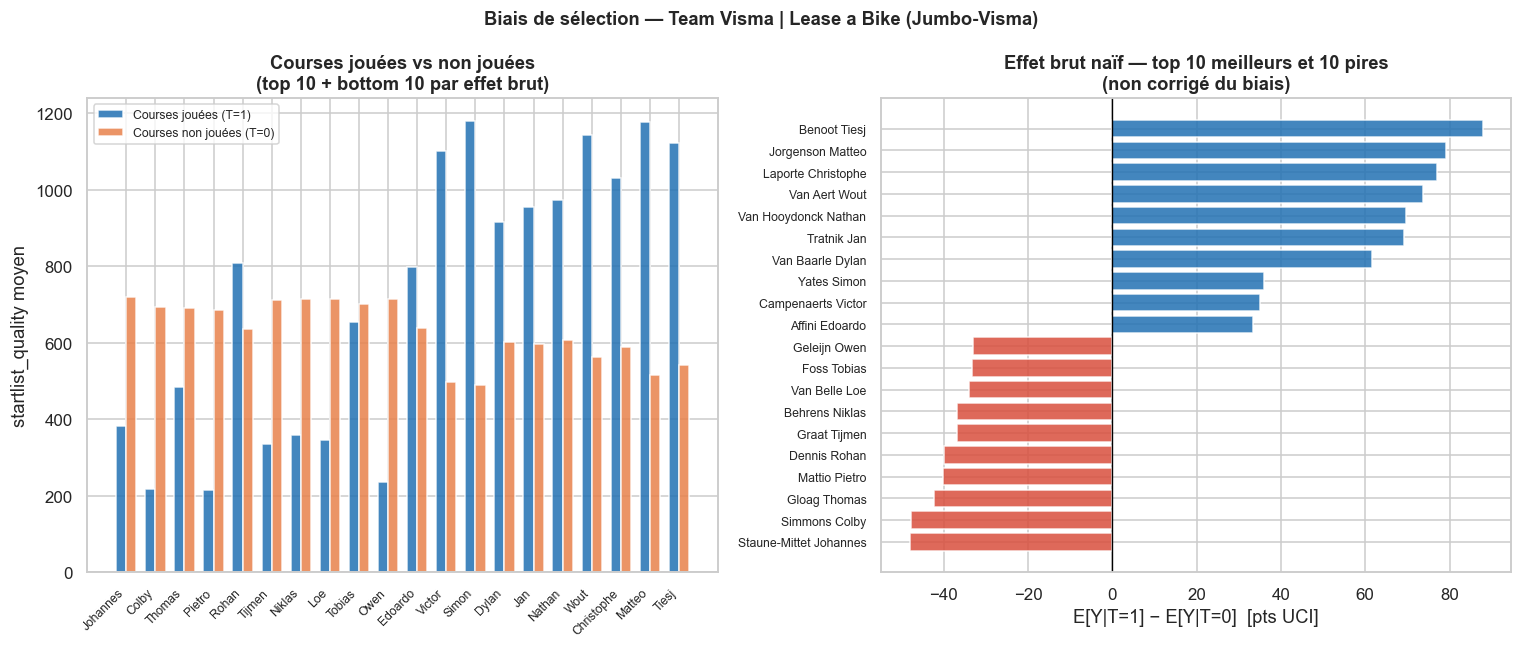

In [5]:
# ── Illustration du biais de sélection — top 10 meilleurs + 10 pires ────────
# On calcule l'effet brut naïf pour tous les coureurs Jumbo, puis on affiche
# les 10 avec le plus grand effet et les 10 avec le plus petit.
rows_b = []
for rn in RIDERS:
    df_r = load_rider(rn, equipe=EQUIPE)
    if df_r is None or len(df_r) < 20:
        continue
    y1 = df_r[df_r[TREATMENT]==1][OUTCOME].dropna()
    y0 = df_r[df_r[TREATMENT]==0][OUTCOME].dropna()
    if len(y1) < 5 or len(y0) < 5:
        continue
    sq1 = df_r[df_r[TREATMENT]==1]['startlist_quality'].dropna().mean() if 'startlist_quality' in df_r.columns else np.nan
    sq0 = df_r[df_r[TREATMENT]==0]['startlist_quality'].dropna().mean() if 'startlist_quality' in df_r.columns else np.nan
    rows_b.append({'rider': rn, 'effet_brut': y1.mean() - y0.mean(),
                   'sq_present': sq1, 'sq_absent': sq0, 'n_sel': len(y1)})

df_brut_all = pd.DataFrame(rows_b)
top10 = df_brut_all.nlargest(10, 'effet_brut')
bot10 = df_brut_all.nsmallest(10, 'effet_brut')
df_bias = pd.concat([top10, bot10]).drop_duplicates('rider').sort_values('effet_brut')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Niveau du peloton : courses jouées vs non jouées
ax = axes[0]
df_sq = df_bias.dropna(subset=['sq_present', 'sq_absent']).reset_index(drop=True)
x = np.arange(len(df_sq))
w = 0.35
ax.bar(x - w/2, df_sq['sq_present'], w, label='Courses jouées (T=1)',
       color=C_BLUE, edgecolor='white', alpha=0.85)
ax.bar(x + w/2, df_sq['sq_absent'],  w, label='Courses non jouées (T=0)',
       color=C_ORANGE, edgecolor='white', alpha=0.85)
names = [r.replace('_', ' ').title().split()[-1] for r in df_sq['rider']]
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('startlist_quality moyen')
ax.set_title('Courses jouées vs non jouées\n(top 10 + bottom 10 par effet brut)',
             fontweight='bold')
ax.legend(fontsize=8)

# Effet brut — top 10 et bottom 10
ax = axes[1]
colors_b = [C_BLUE if v >= 0 else C_RED for v in df_bias['effet_brut']]
ax.barh(range(len(df_bias)), df_bias['effet_brut'], color=colors_b,
        edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_yticks(range(len(df_bias)))
ax.set_yticklabels([r.replace('_', ' ').title()[:22] for r in df_bias['rider']], fontsize=8)
ax.set_xlabel('E[Y|T=1] − E[Y|T=0]  [pts UCI]')
ax.set_title('Effet brut naïf — top 10 meilleurs et 10 pires\n(non corrigé du biais)',
             fontweight='bold')

plt.suptitle(f'Biais de sélection — {EQUIPE_LABEL}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Double Machine Learning (DML) — ATE par coureur

### Principe

Le DML (Chernozhukov et al., 2018) estime l'**ATE** (Average Treatment Effect) en deux étapes :

**Étape 1 — Résidu du traitement :**
$$\tilde{T} = T - \hat{E}[T|X] = \text{selected} - \text{GBM}(X)$$
Ce résidu capture les **présences anormales** : quand un coureur est sélectionné sur une course où son équipe ne l'envoie habituellement pas.

**Étape 2 — Résidu de l'outcome :**
$$\tilde{Y} = Y - \hat{E}[Y|X] = \log(1+\text{pts\_eq}) - \text{GBM}(X)$$
Ce résidu capture les **performances anormales** de l'équipe, non expliquées par le type de course.

**Étape 3 — ATE :**
$$\text{ATE} = \frac{\text{Cov}(\tilde{Y}, \tilde{T})}{\text{Var}(\tilde{T})}$$

Si les performances anormales coïncident avec les présences anormales → effet positif.

**Cross-fitting** (5 folds) : les résidus sont calculés hors échantillon → évite le surapprentissage.

**Bootstrap** (500 iter.) : intervalle de confiance à 95%.

In [6]:
def run_dml(X, T, Y, n_folds=N_FOLDS, n_boot=N_BOOT, random_state=RANDOM_STATE):
    """
    Double Machine Learning avec cross-fitting et bootstrap.

    Retourne un dict avec :
    - ate_log   : ATE sur l'échelle log(1+Y)
    - ate_orig  : ATE approximatif sur l'échelle originale (expm1)
    - ci_low/ci_high : IC 95% bootstrap (échelle originale)
    - significant    : True si l'IC ne contient pas 0
    - r2_y / r2_t    : R² des modèles nuisance (qualité du contrôle)
    - T_resid / Y_resid : résidus du cross-fitting
    """
    # Vérifier la variance dans T
    if T.sum() < 5 or (T == 0).sum() < 5:
        return None

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    T_resid = np.zeros(len(T))
    Y_resid = np.zeros(len(Y))
    r2_t_folds, r2_y_folds = [], []

    for train_idx, val_idx in kf.split(X):
        # Modèle nuisance pour T (probabilité de sélection)
        m_t = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=random_state)
        m_t.fit(X[train_idx], T[train_idx])
        T_pred = m_t.predict(X[val_idx])
        T_resid[val_idx] = T[val_idx] - T_pred
        r2_t_folds.append(r2_score(T[val_idx], T_pred))

        # Modèle nuisance pour Y (performance équipe attendue)
        m_y = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=random_state)
        m_y.fit(X[train_idx], Y[train_idx])
        Y_pred = m_y.predict(X[val_idx])
        Y_resid[val_idx] = Y[val_idx] - Y_pred
        r2_y_folds.append(r2_score(Y[val_idx], Y_pred))

    # ATE via régression des résidus
    ate = np.cov(Y_resid, T_resid)[0, 1] / (np.var(T_resid) + 1e-10)

    # Bootstrap pour IC 95%
    rng = np.random.default_rng(random_state)
    boots = []
    for _ in range(n_boot):
        idx = rng.choice(len(T_resid), len(T_resid), replace=True)
        cov_b = np.cov(Y_resid[idx], T_resid[idx])
        boots.append(cov_b[0, 1] / (np.var(T_resid[idx]) + 1e-10))
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

    return {
        'ate_log'    : ate,
        'ate_orig'   : np.expm1(ate),
        'ci_low'     : np.expm1(ci_low),
        'ci_high'    : np.expm1(ci_high),
        'significant': ci_low > 0 or ci_high < 0,
        'r2_t'       : np.mean(r2_t_folds),
        'r2_y'       : np.mean(r2_y_folds),
        'T_resid'    : T_resid,
        'Y_resid'    : Y_resid,
    }


print('✅ Fonction DML chargée')

✅ Fonction DML chargée


In [7]:
# ── DML sur tous les coureurs de l'équipe ───────────────────────────────────
print(f'DML — {EQUIPE_LABEL} | Chargement et calcul...\n')

results_dml = []
for rider_name in RIDERS:
    df_r = load_rider(rider_name, annee=None, equipe=EQUIPE)
    if df_r is None:
        continue
    prep = prepare_features(df_r)
    if prep is None:
        continue
    X_r, T_r, Y_r, df_clean_r, feats = prep

    brut = (df_clean_r[df_clean_r[TREATMENT]==1][OUTCOME].mean() -
            df_clean_r[df_clean_r[TREATMENT]==0][OUTCOME].mean())

    res = run_dml(X_r, T_r, Y_r)
    if res:
        results_dml.append({
            'rider'      : rider_name,
            'n_obs'      : len(T_r),
            'n_selected' : int(T_r.sum()),
            'taux_sel'   : T_r.mean(),
            'ate_orig'   : res['ate_orig'],
            'ci_low'     : res['ci_low'],
            'ci_high'    : res['ci_high'],
            'significant': res['significant'],
            'effet_brut' : brut,
            'r2_t'       : res['r2_t'],
            'r2_y'       : res['r2_y'],
        })
        sig = '✓' if res['significant'] else ' '
        print(f'  [{sig}] {rider_name:<40}  ATE={res["ate_orig"]:+6.2f}  '
              f'IC=[{res["ci_low"]:+5.2f}, {res["ci_high"]:+5.2f}]  '
              f'R²_t={res["r2_t"]:.2f}  R²_y={res["r2_y"]:.2f}')

df_results = pd.DataFrame(results_dml).sort_values('ate_orig', ascending=False)
print(f'\n→ {len(df_results)} coureurs analysés | {df_results["significant"].sum()} effets significatifs')

DML — Team Visma | Lease a Bike (Jumbo-Visma) | Chargement et calcul...

  [ ] affini_edoardo                            ATE= +0.13  IC=[-0.20, +0.61]  R²_t=0.53  R²_y=0.25
  [ ] battaglin_enrico                          ATE= +0.69  IC=[-0.24, +2.79]  R²_t=0.56  R²_y=0.03
  [ ] behrens_niklas                            ATE= +0.21  IC=[-0.41, +1.62]  R²_t=0.38  R²_y=0.20
  [ ] bennett_george                            ATE= +0.08  IC=[-0.25, +0.58]  R²_t=0.60  R²_y=0.22
  [ ] benoot_tiesj                              ATE= +0.36  IC=[-0.21, +1.18]  R²_t=0.70  R²_y=0.25
  [ ] boom_lars                                 ATE= -0.38  IC=[-0.66, +0.20]  R²_t=0.39  R²_y=-0.00
  [ ] bouwman_koen                              ATE= -0.14  IC=[-0.33, +0.14]  R²_t=0.45  R²_y=0.22
  [ ] boven_lars                                ATE= +0.19  IC=[-0.39, +1.38]  R²_t=0.07  R²_y=0.24
  [ ] brennan_matthew                           ATE= +0.52  IC=[-0.19, +1.91]  R²_t=0.42  R²_y=0.23
  [ ] campenaerts_victor  

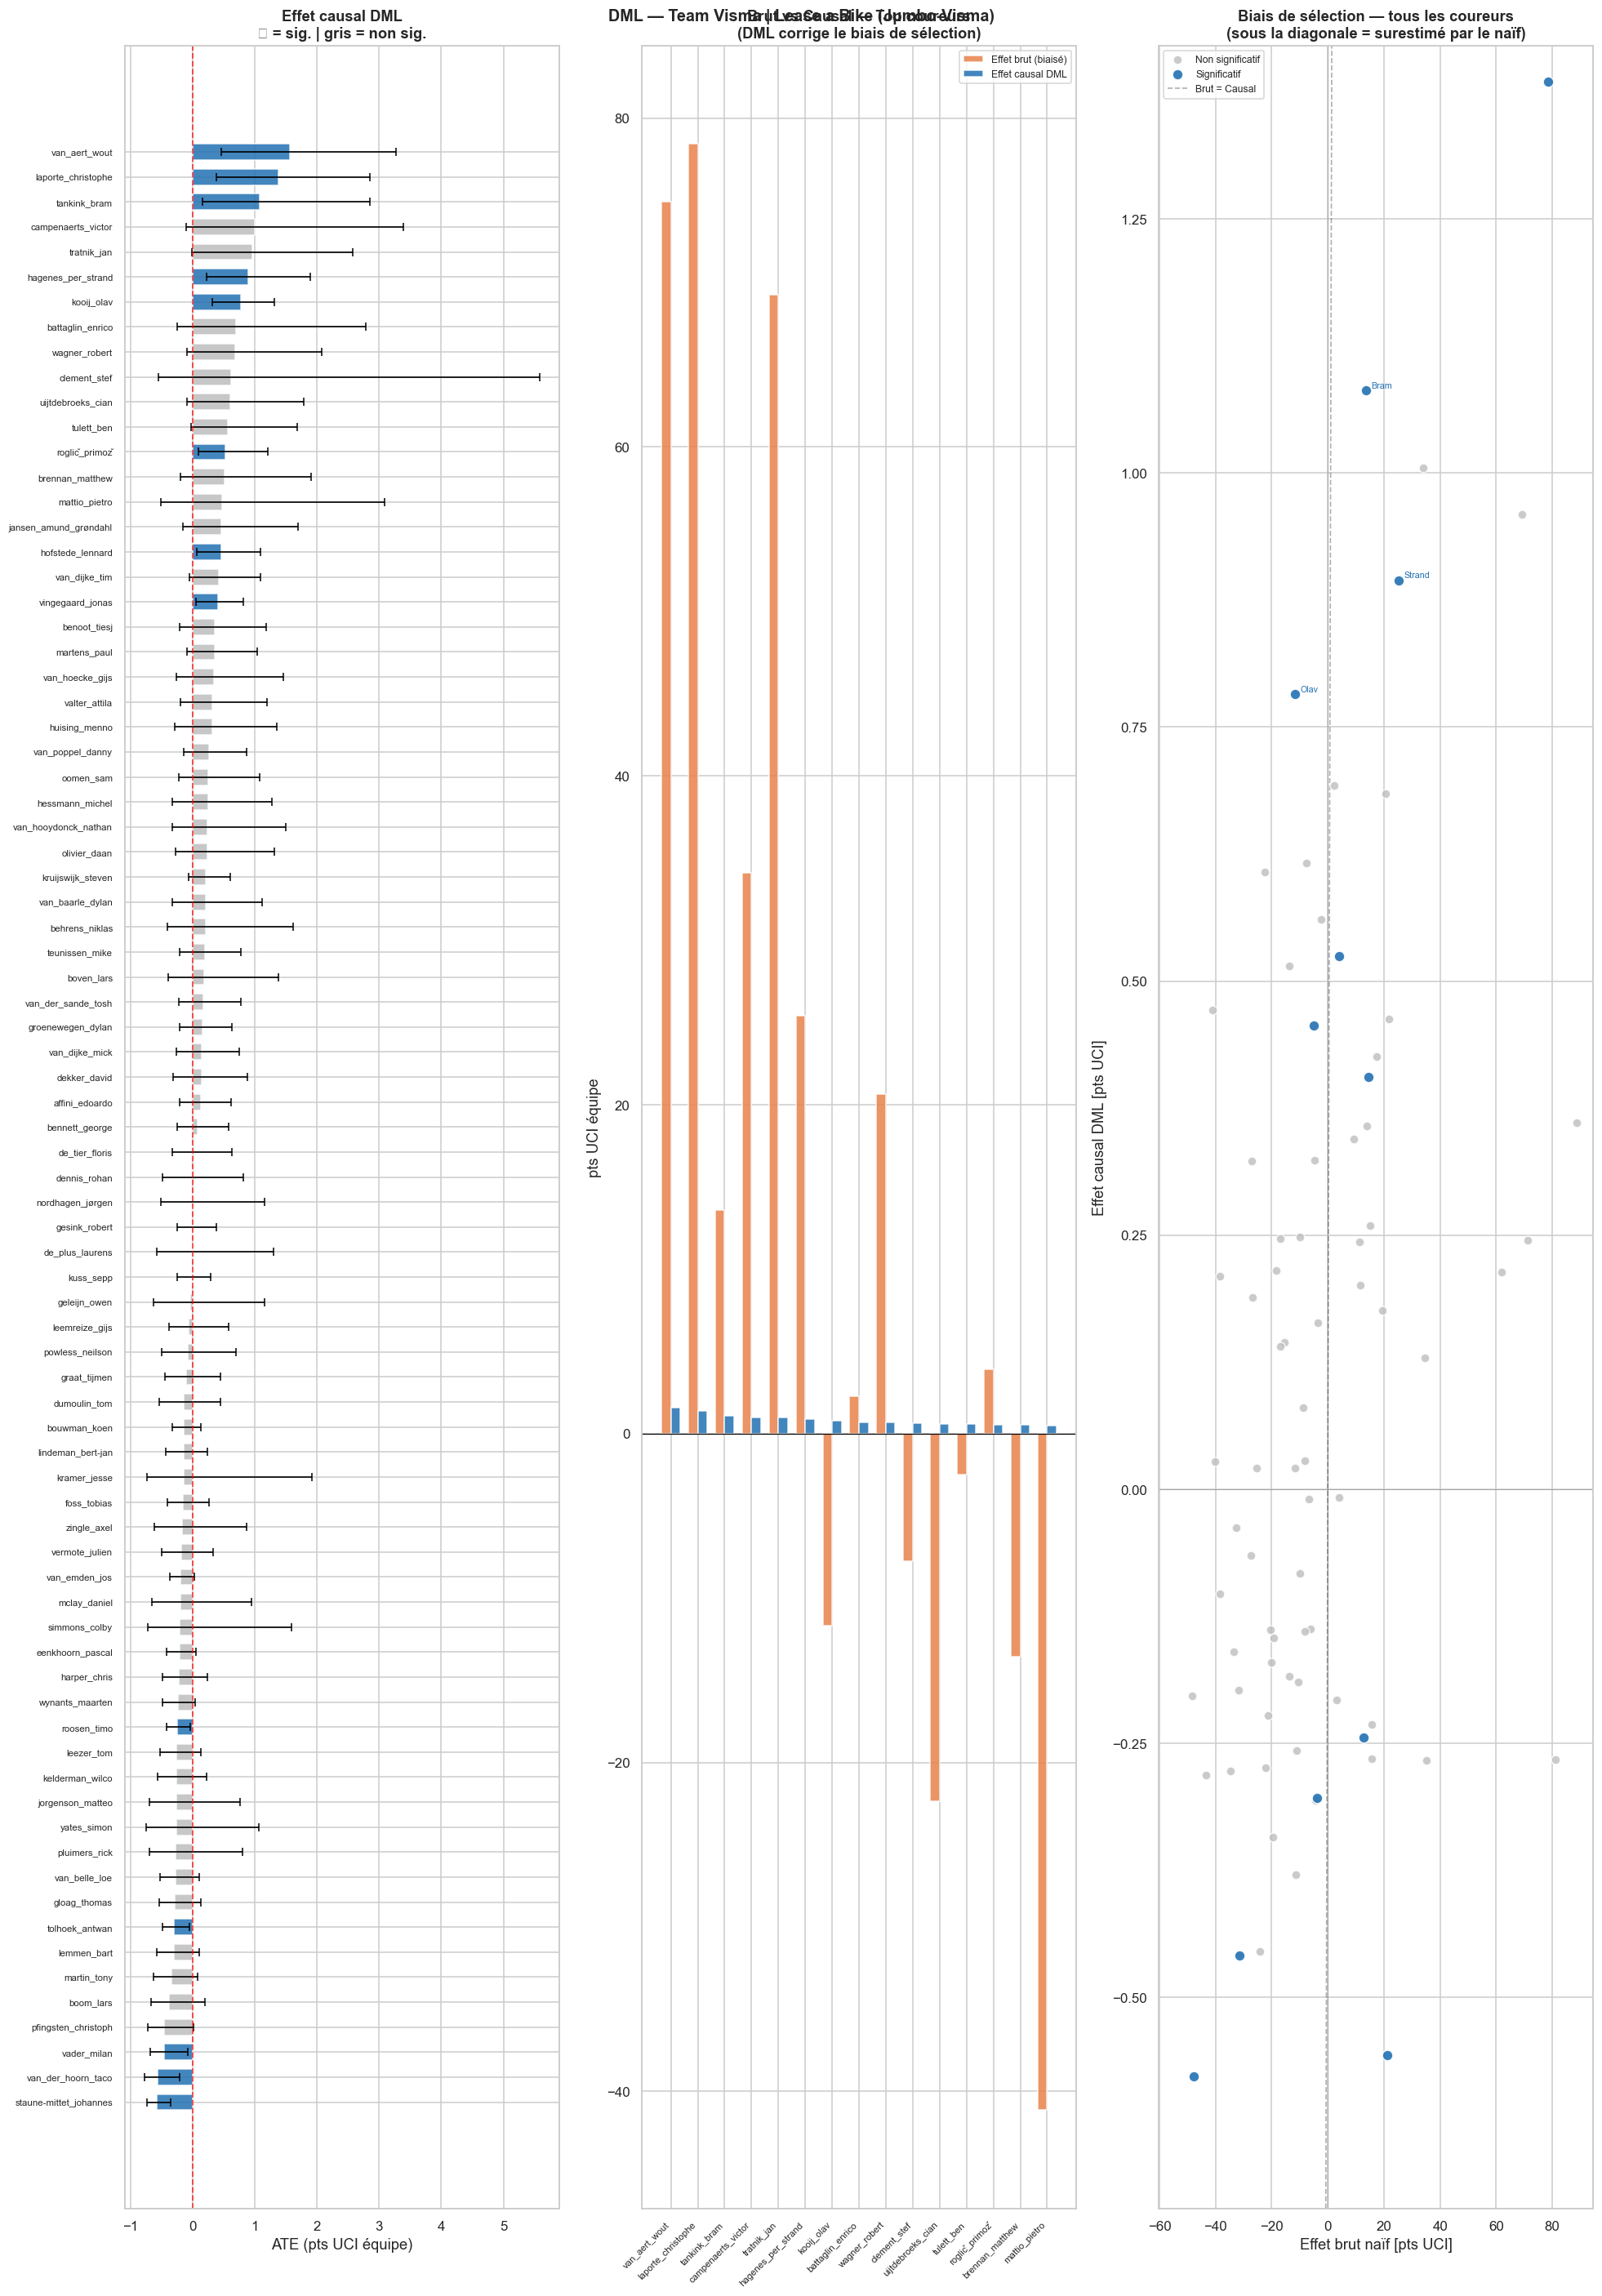


Tableau résumé DML :
                 rider  n_selected  taux_sel  ate_orig  ci_low  ci_high  significant  effet_brut
         van_aert_wout         318     0.210     1.568   0.463    3.267         True      74.930
    laporte_christophe         166     0.178     1.385   0.385    2.846         True      78.437
          tankink_bram          42     0.170     1.081   0.158    2.856         True      13.577
    campenaerts_victor          63     0.258     1.005  -0.106    3.391        False      34.093
           tratnik_jan         101     0.218     0.959  -0.009    2.578        False      69.265
    hagenes_per_strand          98     0.105     0.894   0.229    1.888         True      25.387
            kooij_olav         261     0.206     0.782   0.317    1.322         True     -11.670
      battaglin_enrico          72     0.291     0.693  -0.242    2.789        False       2.252
         wagner_robert          35     0.142     0.684  -0.096    2.079        False      20.646
        

In [8]:
# ── Visualisation DML ───────────────────────────────────────────────────────
if len(df_results) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(df_results)*0.33)))

    # Forest plot : ATE + IC
    df_plot = df_results.sort_values('ate_orig', ascending=True)
    colors_f = [C_BLUE if s else C_GRAY for s in df_plot['significant']]
    y_pos = range(len(df_plot))

    ax = axes[0]
    ax.barh(y_pos, df_plot['ate_orig'], color=colors_f,
            edgecolor='white', alpha=0.85, height=0.65)
    ax.errorbar(
        df_plot['ate_orig'], y_pos,
        xerr=[
            (df_plot['ate_orig'] - df_plot['ci_low']).clip(lower=0),
            (df_plot['ci_high'] - df_plot['ate_orig']).clip(lower=0)
        ],
        fmt='none', color='black', capsize=3, linewidth=1.1
    )
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['rider'], fontsize=7.5)
    ax.set_xlabel('ATE (pts UCI équipe)')
    ax.set_title('Effet causal DML\n✓ = sig. | gris = non sig.', fontweight='bold')

    # Brut vs Causal
    ax = axes[1]
    df_top = df_results.head(min(15, len(df_results)))
    x = np.arange(len(df_top))
    w = 0.35
    ax.bar(x - w/2, df_top['effet_brut'], w, label='Effet brut (biaisé)',
           color=C_ORANGE, alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, df_top['ate_orig'],   w, label='Effet causal DML',
           color=C_BLUE, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_top['rider'], rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel('pts UCI équipe')
    ax.set_title('Brut vs Causal — Top coureurs\n(DML corrige le biais de sélection)', fontweight='bold')
    ax.legend(fontsize=8)

    # Scatter brut vs causal — axes clippés aux percentiles 2-98%
    ax = axes[2]
    sig = df_results['significant']
    ax.scatter(df_results.loc[~sig, 'effet_brut'], df_results.loc[~sig, 'ate_orig'],
               color=C_GRAY, s=50, alpha=0.8, label='Non significatif', edgecolors='white', zorder=3)
    ax.scatter(df_results.loc[sig, 'effet_brut'], df_results.loc[sig, 'ate_orig'],
               color=C_BLUE, s=70, alpha=0.9, label='Significatif', edgecolors='white', zorder=4)
    # Axes basés sur les percentiles pour éviter les outliers
    x_lo, x_hi = np.percentile(df_results['effet_brut'].dropna(), [2, 98])
    y_lo, y_hi = np.percentile(df_results['ate_orig'].dropna(), [2, 98])
    mx = (x_hi - x_lo) * 0.12
    my = (y_hi - y_lo) * 0.12
    ax.set_xlim(x_lo - mx, x_hi + mx)
    ax.set_ylim(y_lo - my, y_hi + my)
    # Ligne diagonale sur la plage visible
    lo = max(x_lo - mx, y_lo - my)
    hi = min(x_hi + mx, y_hi + my)
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, linewidth=1.1, label='Brut = Causal')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
    for _, row in df_results[df_results['significant']].nlargest(5, 'ate_orig').iterrows():
        if x_lo <= row['effet_brut'] <= x_hi and y_lo <= row['ate_orig'] <= y_hi:
            ax.annotate(row['rider'].split('_')[-1].title(),
                        (row['effet_brut'], row['ate_orig']),
                        textcoords='offset points', xytext=(4, 2), fontsize=7, color=C_BLUE)
    ax.set_xlabel('Effet brut naïf [pts UCI]')
    ax.set_ylabel('Effet causal DML [pts UCI]')
    ax.set_title('Biais de sélection — tous les coureurs\n(sous la diagonale = surestimé par le naïf)',
                 fontweight='bold')
    ax.legend(fontsize=8)

    plt.suptitle(f'DML — {EQUIPE_LABEL}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nTableau résumé DML :')
    print(df_results[['rider', 'n_selected', 'taux_sel', 'ate_orig',
                       'ci_low', 'ci_high', 'significant', 'effet_brut']]
          .to_string(index=False))


## 4.5 — Analyse détaillée par coureur — toutes les variables

Pour chaque coureur de l'équipe, on présente :
1. **Tableau complet** : ATE, profil de course, contexte dynamique, niveau de compétition
2. **Profil de sélection** : différence normalisée entre les courses où le coureur est présent vs absent → révèle le biais de sélection
3. **Décomposition par année et cluster**

In [9]:
# ── Tableau complet par coureur ──────────────────────────────────────────────
rows_detail = []
for rider_name in RIDERS:
    df_r = load_rider(rider_name, equipe=EQUIPE)
    if df_r is None or len(df_r) < 10:
        continue

    sel1 = df_r[df_r[TREATMENT] == 1]
    sel0 = df_r[df_r[TREATMENT] == 0]

    ate_row = df_results[df_results['rider'] == rider_name] if len(df_results) > 0 else pd.DataFrame()

    def _m(df, col):
        return df[col].mean() if col in df.columns and len(df) > 0 else np.nan

    top_cluster = (sel1['stage_cluster_label'].value_counts().index[0]
                   if 'stage_cluster_label' in sel1.columns and len(sel1) > 0 else '')

    row = {
        'coureur'            : rider_name.replace('_', ' ').title(),
        'n_total'            : len(df_r),
        'n_sel'              : len(sel1),
        'n_abs'              : len(sel0),
        'taux_sel_%'         : round(len(sel1) / len(df_r) * 100, 1),
        'annees'             : f"{int(df_r['year'].min())}–{int(df_r['year'].max())}",
        'ATE'                : round(ate_row.iloc[0]['ate_orig'],   2) if len(ate_row) > 0 else np.nan,
        'IC_95%'             : (f"[{ate_row.iloc[0]['ci_low']:+.1f}, {ate_row.iloc[0]['ci_high']:+.1f}]"
                                if len(ate_row) > 0 else ''),
        'sig'                : ('✓' if len(ate_row) > 0 and ate_row.iloc[0]['significant'] else ''),
        'R²_T'               : round(ate_row.iloc[0]['r2_t'], 3) if len(ate_row) > 0 else np.nan,
        'R²_Y'               : round(ate_row.iloc[0]['r2_y'], 3) if len(ate_row) > 0 else np.nan,
        'cluster_principal'  : top_cluster,
        # Course profile (when selected)
        'dist_km'            : round(_m(sel1, 'distance_gpx_km'), 0),
        'déniv_m'            : round(_m(sel1, 'denivele_pos'),     0),
        'n_HC'               : round(_m(sel1, 'n_cols_hc'),        2),
        'grad_1km_%'         : round(_m(sel1, 'gradient_last_1km'),2),
        'cobbles_km'         : round(_m(sel1, 'cobblestones_km'),  2),
        'gravel_km'          : round(_m(sel1, 'compacted_gravel_km'), 2),
        # Dynamic
        'forme_éq'           : round(_m(sel1, 'forme_equipe'),     1),
        'n_courses_30j'      : round(_m(sel1, 'n_races_30d'),      1),
        'km_30j'             : round(_m(sel1, 'km_30d'),           0),
        'leader_rate_%'      : round(_m(sel1, 'leader_played') * 100, 1),
        # PCS
        'startlist_moy'      : round(_m(sel1, 'startlist_quality'),0),
        'temp_moy_°C'        : round(_m(sel1, 'avg_temperature'),  1),
        # Outcome (when selected)
        'Y_sel_moy'          : round(_m(sel1, OUTCOME),  1),
        'Y_abs_moy'          : round(_m(sel0, OUTCOME),  1),
        'pts_uci_moy'        : round(_m(sel1, 'pts_uci'),1),
        'rang_moy'           : round(_m(sel1, 'rang'),   0),
    }
    rows_detail.append(row)

df_detail = pd.DataFrame(rows_detail)
df_detail = df_detail.sort_values('ATE', ascending=False).reset_index(drop=True)

# Affichage
print(f'=== Tableau complet — {EQUIPE_LABEL} ===\n')
print('— Identité & modèle causal —')
id_cols = ['coureur','n_total','n_sel','taux_sel_%','annees','ATE','IC_95%','sig','R²_T','R²_Y']
print(df_detail[[c for c in id_cols if c in df_detail.columns]].to_string(index=False))

print('\n— Profil de course (quand sélectionné) —')
race_cols = ['coureur','dist_km','déniv_m','n_HC','grad_1km_%','cobbles_km','gravel_km','cluster_principal']
print(df_detail[[c for c in race_cols if c in df_detail.columns]].to_string(index=False))

print('\n— Contexte dynamique & PCS —')
dyn_cols = ['coureur','forme_éq','n_courses_30j','km_30j','leader_rate_%','startlist_moy','temp_moy_°C']
print(df_detail[[c for c in dyn_cols if c in df_detail.columns]].to_string(index=False))

print('\n— Performance outcome —')
out_cols = ['coureur','Y_sel_moy','Y_abs_moy','pts_uci_moy','rang_moy']
print(df_detail[[c for c in out_cols if c in df_detail.columns]].to_string(index=False))

=== Tableau complet — Team Visma | Lease a Bike (Jumbo-Visma) ===

— Identité & modèle causal —
               coureur  n_total  n_sel  taux_sel_%    annees    ATE       IC_95% sig   R²_T   R²_Y
         Van Aert Wout     1562    322      20.600 2019–2025  1.570 [+0.5, +3.3]   ✓  0.815  0.256
    Laporte Christophe      965    168      17.400 2022–2025  1.380 [+0.4, +2.8]   ✓  0.634  0.264
          Tankink Bram      251     43      17.100 2018–2018  1.080 [+0.2, +2.9]   ✓  0.200 -0.023
    Campenaerts Victor      253     63      24.900 2025–2025  1.010 [-0.1, +3.4]      0.608  0.123
           Tratnik Jan      480    101      21.000 2023–2024  0.960 [-0.0, +2.6]      0.626  0.122
    Hagenes Per Strand      965     98      10.200 2022–2025  0.890 [+0.2, +1.9]   ✓  0.244  0.251
            Kooij Olav     1312    267      20.400 2020–2025  0.780 [+0.3, +1.3]   ✓  0.388  0.264
      Battaglin Enrico      251     72      28.700 2018–2018  0.690 [-0.2, +2.8]      0.559  0.027
         Wagn

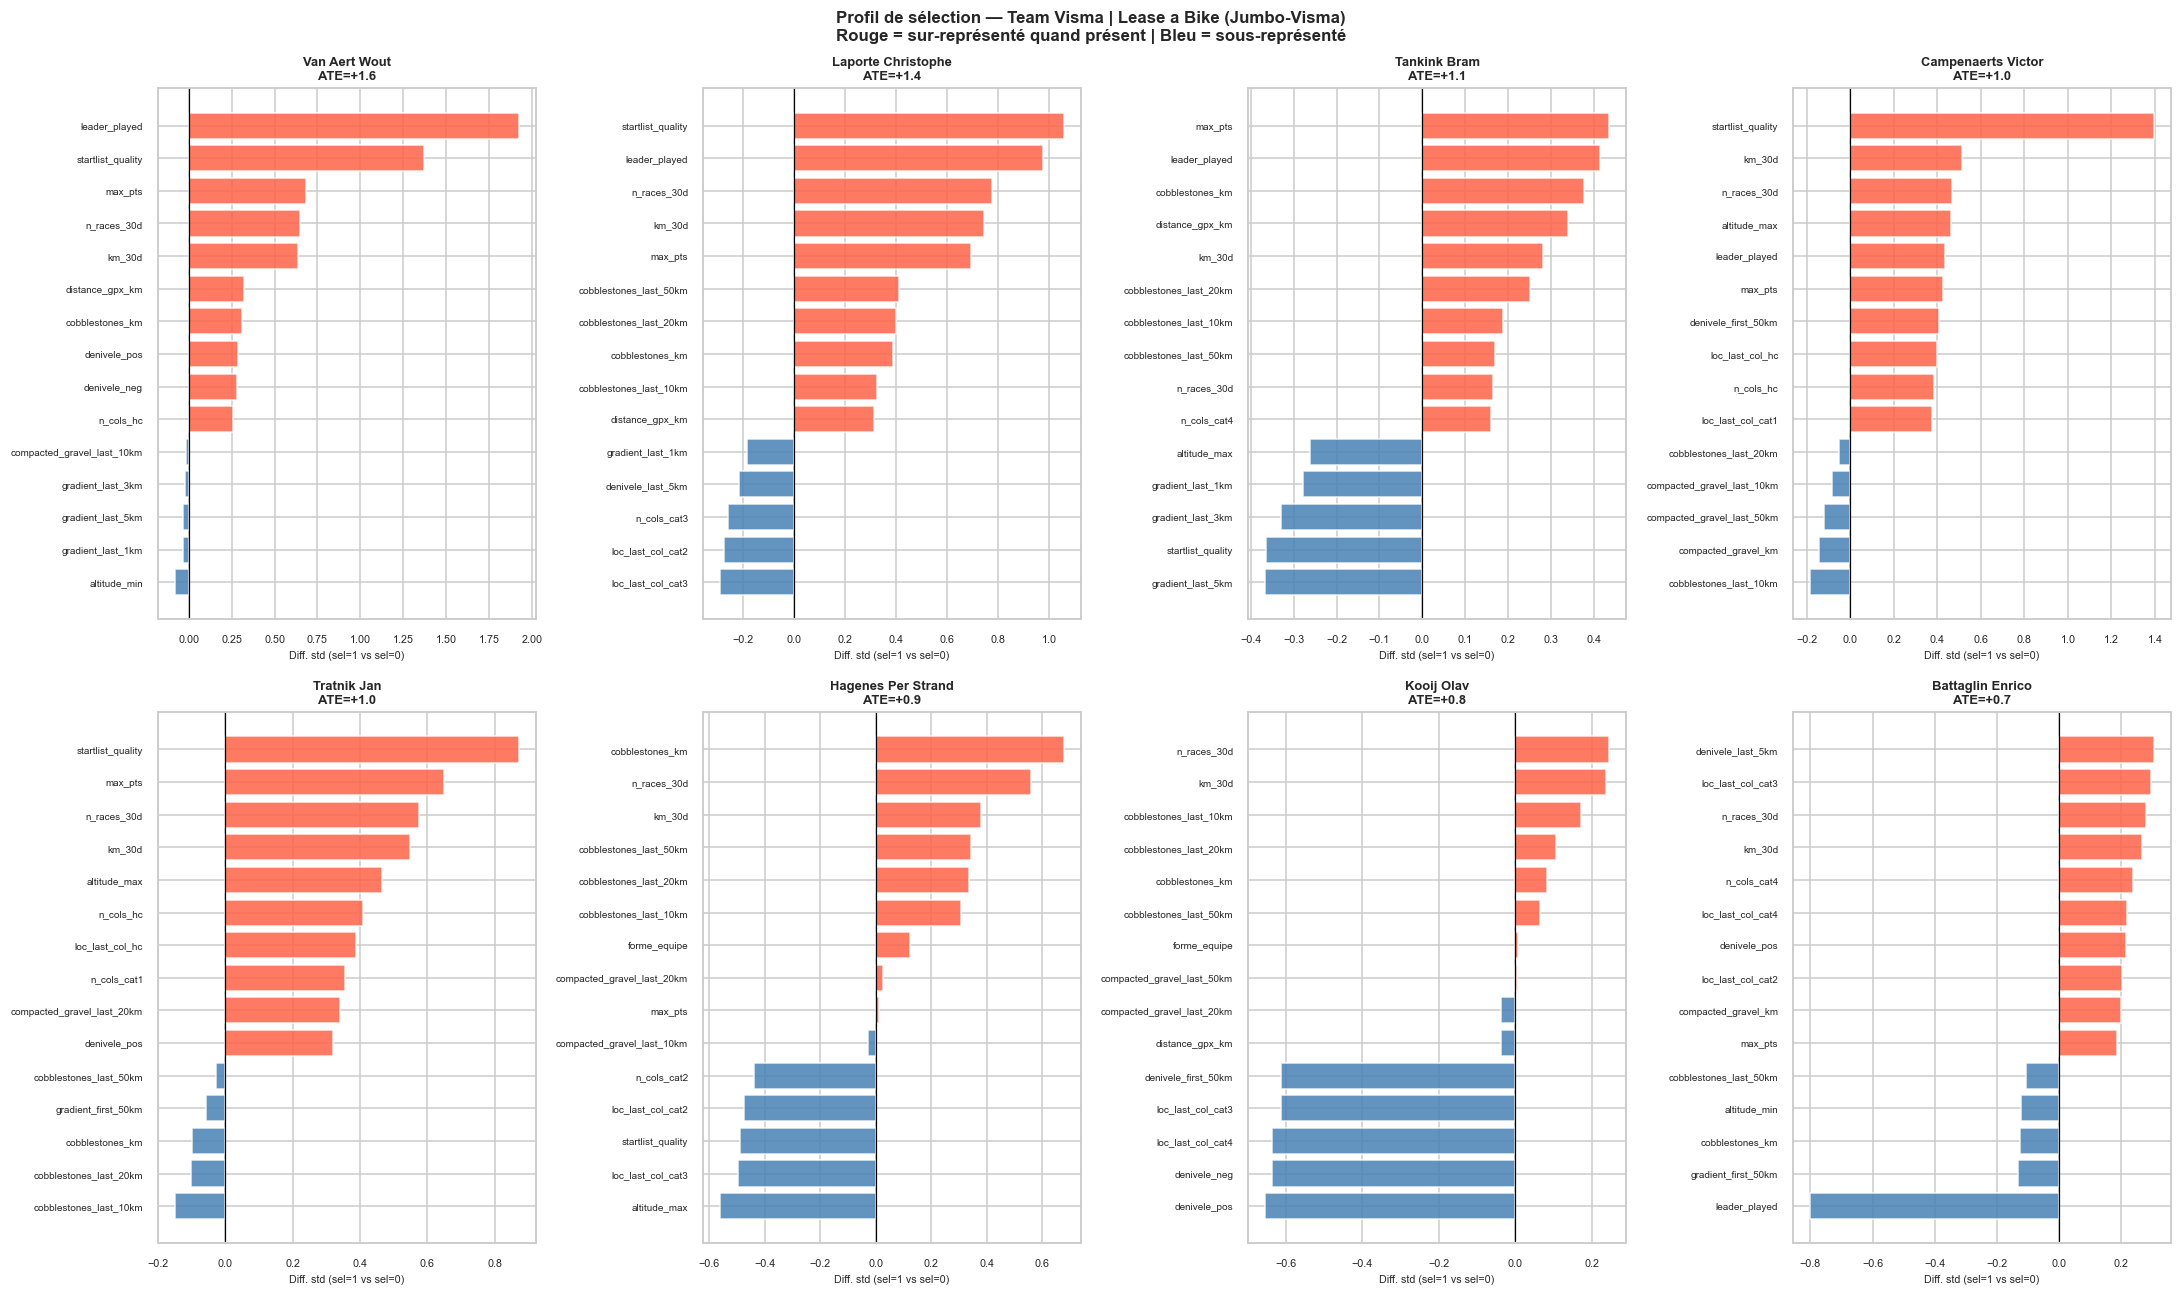

In [10]:
# ── Profil de sélection par coureur — différence normalisée (toutes variables) ──
# Pour chaque variable, on montre comment les courses des coureurs sélectionnés
# diffèrent de celles où ils sont absents. C'est la mesure du biais de sélection.

TOP_N = min(8, len(df_results))
if TOP_N > 0:
    top_riders = df_results.head(TOP_N)['rider'].tolist()

    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    axes = axes.flatten()

    ALL_VARS_DIFF = [c for c in COLS_RACE_ALL + COLS_DYNAMIC_ALL if c != 'avg_temperature']

    for idx, rider_name in enumerate(top_riders):
        ax = axes[idx]
        df_r = load_rider(rider_name, equipe=EQUIPE)
        if df_r is None:
            ax.axis('off')
            continue

        sel1 = df_r[df_r[TREATMENT] == 1]
        sel0 = df_r[df_r[TREATMENT] == 0]

        diffs = []
        for col in ALL_VARS_DIFF:
            if col not in df_r.columns:
                continue
            m1 = pd.to_numeric(sel1[col], errors='coerce').mean()
            m0 = pd.to_numeric(sel0[col], errors='coerce').mean()
            std = pd.to_numeric(df_r[col], errors='coerce').std()
            if std > 0 and not (pd.isna(m1) or pd.isna(m0)):
                diffs.append({'var': col, 'diff_std': (m1 - m0) / std})

        diffs_df = pd.DataFrame(diffs).sort_values('diff_std', ascending=False)
        # Top 10 positives + top 5 negatives
        show = pd.concat([diffs_df.head(10), diffs_df.tail(5)]).drop_duplicates('var')
        show = show.sort_values('diff_std')

        colors = ['tomato' if v > 0 else 'steelblue' for v in show['diff_std']]
        ax.barh(range(len(show)), show['diff_std'], color=colors, edgecolor='white', alpha=0.85)
        ax.set_yticks(range(len(show)))
        ax.set_yticklabels(show['var'], fontsize=6.5)
        ax.axvline(0, color='black', linewidth=0.8)

        # ATE annotation
        ate_val = df_results[df_results['rider']==rider_name]['ate_orig'].values
        ate_str = f'ATE={ate_val[0]:+.1f}' if len(ate_val) > 0 else ''
        ax.set_title(f"{rider_name.replace('_',' ').title()}\n{ate_str}", fontsize=8.5, fontweight='bold')
        ax.set_xlabel('Diff. std (sel=1 vs sel=0)', fontsize=7)
        ax.tick_params(axis='x', labelsize=7)

    plt.suptitle(
        f'Profil de sélection — {EQUIPE_LABEL}\n'
        'Rouge = sur-représenté quand présent | Bleu = sous-représenté',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

## 4.6 — Analyse du leader & contexte d'équipe

**`leader_played`** (0/1) : un leader désigné de l'équipe participait-il à cette course ?

Questions d'intérêt :
- Certains coureurs contribuent-ils plus **en présence** du leader (effet de protection) ?
- D'autres contribuent-ils davantage **sans** le leader (rôle de co-leader) ?
- Qui est le leader en fonction des années/courses ?

=== Proxy leader — classement par pts UCI sur les étapes avec leader_played=1 ===
                       pts_uci_total  n_étapes  pts_uci_moy
rider                                                      
van_aert_wout              14802.000       271       54.620
vingegaard_jonas            3605.000       124       29.073
roglič_primož             2306.000       155       14.877
laporte_christophe          1801.000        88       20.466
groenewegen_dylan           1020.000        63       16.190
kooij_olav                   820.000        30       27.333
jorgenson_matteo             770.000        42       18.333
yates_simon                  647.000        42       15.405
kuss_sepp                    550.000       189        2.910
van_hooydonck_nathan         478.000        83        5.759
benoot_tiesj                 405.000       113        3.584
affini_edoardo               310.000        87        3.563
kelderman_wilco              279.000        81        3.444
teunissen_mike    

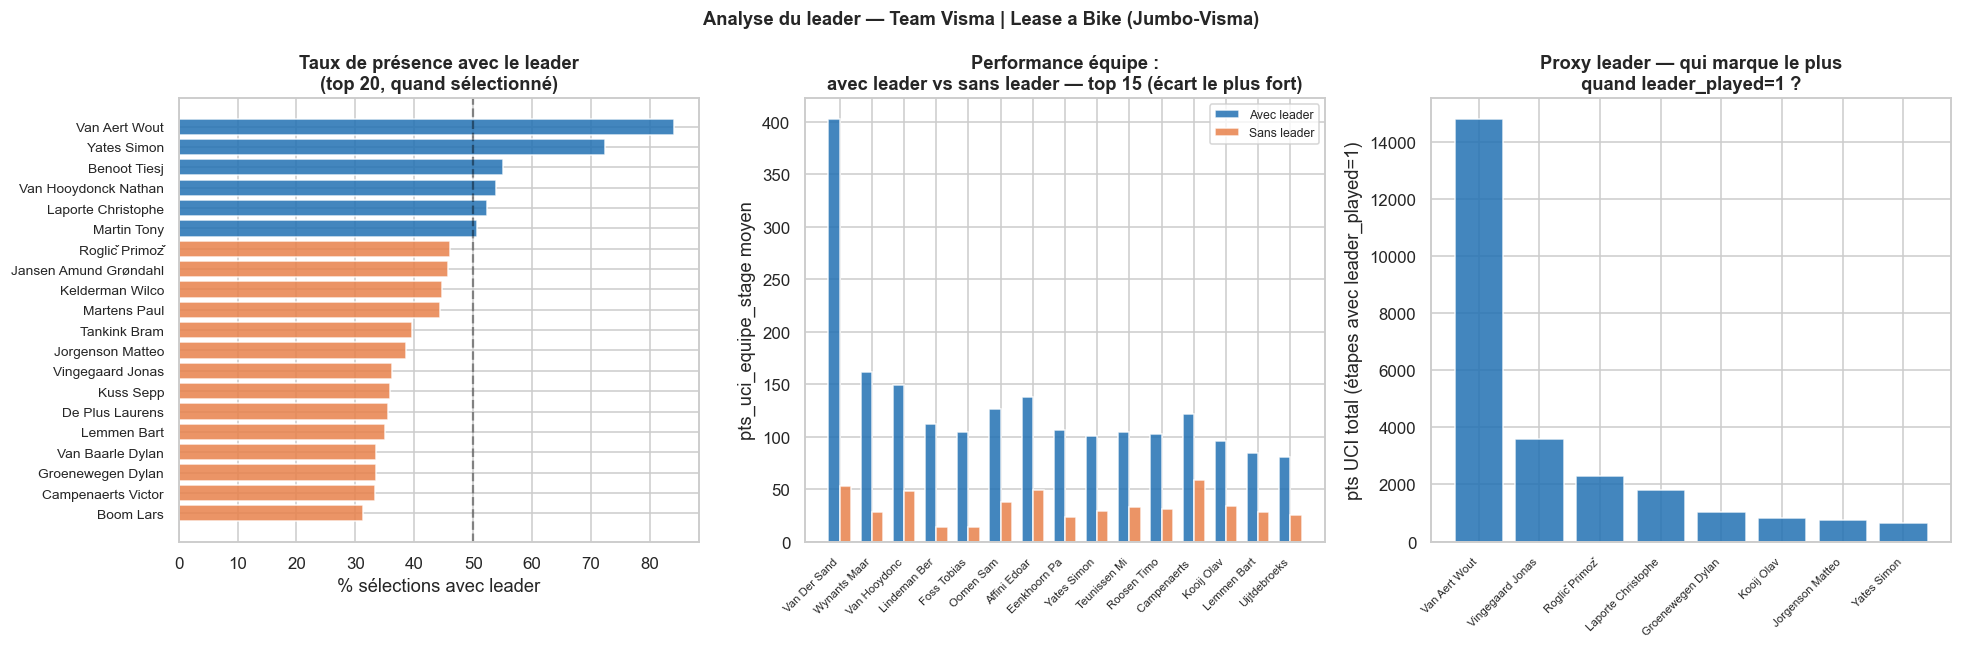

In [11]:
# ── Qui est le leader ? — Identifier le coureur "leader" par course ──────────
# Méthode proxy : parmi les coureurs présents sur les étapes avec leader_played=1,
# le "leader" est identifié comme celui qui marque le plus de pts UCI au total.
# Interprétation : Van Aert marque plus que Vingegaard car il gagne des sprints
# d'étapes lors des GT où Vingegaard joue le GC. Teunissen/Van Hooydonck
# apparaissent en bas du classement — peu de pts, beaucoup d'étapes → vrais domestiques.

all_visma_dfs = []
for rn in RIDERS:
    df_r = load_rider(rn, equipe=EQUIPE)
    if df_r is not None and 'leader_played' in df_r.columns:
        all_visma_dfs.append(df_r[['rider', 'date', 'year', 'course', 'stage_num',
                                    'equipe', 'selected', 'leader_played',
                                    'pts_uci', 'startlist_quality']].copy())

if all_visma_dfs:
    df_visma_all = pd.concat(all_visma_dfs, ignore_index=True)

    df_leader_stages = df_visma_all[
        (df_visma_all['leader_played'] == 1) &
        (df_visma_all['selected'] == 1)
    ].copy()

    leader_proxy = (
        df_leader_stages.groupby('rider')['pts_uci']
        .agg(['sum', 'count', 'mean'])
        .sort_values('sum', ascending=False)
        .head(20)
    )
    leader_proxy.columns = ['pts_uci_total', 'n_étapes', 'pts_uci_moy']
    print('=== Proxy leader — classement par pts UCI sur les étapes avec leader_played=1 ===')
    print(leader_proxy.to_string())

    # ── Exemple sur une course GT ────────────────────────────────────────────
    gt_names = ['tour-de-france', 'giro-d-italia', 'vuelta-a-espana']
    for gt in gt_names:
        ex = df_leader_stages[(df_leader_stages['course'] == gt) &
                               (df_leader_stages['year'] == 2022)]
        if len(ex) > 0:
            ex_sum = ex.groupby('rider')['pts_uci'].sum().sort_values(ascending=False).head(5)
            print(f'\n=== Exemple — {gt} 2022 : proxy leader (pts UCI total sur stages avec leader=1) ===')
            print(ex_sum.to_string())
            break

    print('\n=== Taux de présence avec leader par coureur & année ===')
    lp_year = (
        df_visma_all[df_visma_all['selected'] == 1]
        .groupby(['rider', 'year'])['leader_played']
        .mean()
        .unstack(fill_value=np.nan)
        .round(2)
    )
    print(lp_year.sort_values(
        lp_year.columns[-1] if len(lp_year.columns) > 0 else lp_year.columns[0],
        ascending=False, na_position='last').to_string())

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Taux de présence avec leader — top 20 coureurs
    ax = axes[0]
    lr_df = (df_visma_all[df_visma_all['selected'] == 1]
             .groupby('rider')['leader_played'].mean()
             .sort_values(ascending=True)
             .tail(20))
    colors_lr = [C_BLUE if v > 0.5 else C_ORANGE for v in lr_df.values]
    ax.barh(range(len(lr_df)), lr_df.values * 100, color=colors_lr,
            edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(lr_df)))
    ax.set_yticklabels([r.replace('_', ' ').title() for r in lr_df.index], fontsize=9)
    ax.axvline(50, color='black', linestyle='--', alpha=0.4)
    ax.set_xlabel('% sélections avec leader')
    ax.set_title('Taux de présence avec le leader\n(top 20, quand sélectionné)', fontweight='bold')

    # 2. Performance avec/sans leader
    ax = axes[1]
    rows_lp = []
    for rn in RIDERS:
        df_r = load_rider(rn, equipe=EQUIPE)
        if df_r is None or 'leader_played' not in df_r.columns:
            continue
        s = df_r[df_r[TREATMENT] == 1]
        s1 = s[s['leader_played'] == 1][OUTCOME].mean()
        s0 = s[s['leader_played'] == 0][OUTCOME].mean()
        n1 = (s['leader_played'] == 1).sum()
        n0 = (s['leader_played'] == 0).sum()
        if n1 >= 5 and n0 >= 5:
            rows_lp.append({'rider': rn, 'avec_leader': s1, 'sans_leader': s0,
                            'diff': s1 - s0})

    if rows_lp:
        df_lp = pd.DataFrame(rows_lp).sort_values('diff', ascending=False).head(15)
        x_lp = np.arange(len(df_lp))
        w = 0.35
        ax.bar(x_lp - w/2, df_lp['avec_leader'], w, label='Avec leader',
               color=C_BLUE, alpha=0.85, edgecolor='white')
        ax.bar(x_lp + w/2, df_lp['sans_leader'], w, label='Sans leader',
               color=C_ORANGE, alpha=0.85, edgecolor='white')
        ax.set_xticks(x_lp)
        ax.set_xticklabels([r.replace('_', ' ').title()[:12] for r in df_lp['rider']],
                           rotation=45, ha='right', fontsize=7.5)
        ax.set_ylabel('pts_uci_equipe_stage moyen')
        ax.set_title('Performance équipe :\navec leader vs sans leader — top 15 (écart le plus fort)', fontweight='bold')
        ax.legend(fontsize=8)

    # 3. Proxy leader — pts UCI total quand leader=1
    ax = axes[2]
    if len(leader_proxy) > 0:
        top_l = leader_proxy.head(8)
        ax.bar(range(len(top_l)), top_l['pts_uci_total'],
               color=C_BLUE, edgecolor='white', alpha=0.85)
        ax.set_xticks(range(len(top_l)))
        ax.set_xticklabels([r.replace('_', ' ').title() for r in top_l.index],
                           rotation=45, ha='right', fontsize=7.5)
        ax.set_ylabel('pts UCI total (étapes avec leader_played=1)')
        ax.set_title('Proxy leader — qui marque le plus\nquand leader_played=1 ?', fontweight='bold')

    plt.suptitle(f'Analyse du leader — {EQUIPE_LABEL}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 5. Causal Forest — CATE hétérogène

### Pourquoi aller au-delà de l'ATE ?

L'ATE donne **un seul chiffre** pour tous les contextes. Mais la vraie question sportive est :
> *Grégoire apporte-t-il autant sur Paris-Roubaix (pavés) que sur l'Alpe d'Huez (montagne) ?*

Le **Causal Forest DML** (Wager & Athey, 2018 ; implémenté dans EconML) estime un **CATE** pour chaque observation :
$$\tau(x) = E[Y(1) - Y(0) | X = x]$$

→ **Hétérogénéité** : l'effet dépend du profil de la course.

### Utilisation pratique
Pour un coureur donné, on sait sur quel **type de course** il contribue le plus → optimisation du calendrier.

In [12]:
def run_causal_forest(X, T, Y, n_estimators=N_TREES, random_state=RANDOM_STATE):
    """
    Entraîne un Causal Forest DML et retourne les CATE.
    """
    cf = CausalForestDML(
        model_y      = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=random_state),
        model_t      = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=random_state),
        n_estimators = n_estimators,
        random_state = random_state,
        cv           = 5,
        inference    = True,   # pour les intervalles de confiance sur le CATE
    )
    cf.fit(Y, T, X=X)
    cate = cf.effect(X)
    return cf, cate


print('✅ Fonction Causal Forest chargée')

✅ Fonction Causal Forest chargée


In [13]:
# ── Configuration Causal Forest ──────────────────────────────────────────────
# Modifier COUREURS_CF pour analyser d'autres coureurs.

COUREURS_CF = [
    'van_aert_wout',
    'vingegaard_jonas',
    'campenaerts_victor',
]

# Coureur principal pour la visualisation détaillée (premier de la liste par défaut)
_focus_candidates = [r for r in COUREURS_CF if r in RIDERS]
COUREUR_FOCUS = _focus_candidates[0] if _focus_candidates else (
    df_results.iloc[0]['rider'] if len(df_results) > 0 else (RIDERS[0] if RIDERS else None)
)

print(f'Coureurs CF : {COUREURS_CF}')
print(f'Coureur focus : {COUREUR_FOCUS}')
print(f'Coureurs disponibles dans RIDERS : {_focus_candidates}')


Coureurs CF : ['van_aert_wout', 'vingegaard_jonas', 'campenaerts_victor']
Coureur focus : van_aert_wout
Coureurs disponibles dans RIDERS : ['van_aert_wout', 'vingegaard_jonas', 'campenaerts_victor']


In [14]:
# ── Causal Forest sur les coureurs focus ─────────────────────────────────────
cf_store = {}   # {rider_name: (cf_model, cate, df_clean, feats)}

riders_to_run = [r for r in COUREURS_CF if r in RIDERS]
if not riders_to_run and COUREUR_FOCUS:
    riders_to_run = [COUREUR_FOCUS]

for rider_name in riders_to_run:
    print(f'Causal Forest — {rider_name}')
    df_r  = load_rider(rider_name, equipe=EQUIPE)
    prep_r = prepare_features(df_r)
    if prep_r is None:
        print(f'  ⚠️  Données insuffisantes')
        continue
    X_r, T_r, Y_r, df_clean_r, feats_r = prep_r
    print(f'  N obs: {len(T_r)} | selected=1: {int(T_r.sum())} | selected=0: {int((T_r==0).sum())}')
    cf_r, cate_r = run_causal_forest(X_r, T_r, Y_r)
    df_clean_r = df_clean_r.copy()
    df_clean_r['cate']  = cate_r
    df_clean_r['rider'] = rider_name
    cf_store[rider_name] = (cf_r, cate_r, df_clean_r, feats_r)
    print(f'  CATE moy={cate_r.mean():.3f} | std={cate_r.std():.3f} | %positifs={(cate_r>0).mean()*100:.1f}%')
    print()

# Variables globales pour la visualisation du coureur focus
prep_f = None
if COUREUR_FOCUS and COUREUR_FOCUS in cf_store:
    cf_model, cate, df_f_clean, feats_f = cf_store[COUREUR_FOCUS]
    prep_f = True
    print(f'✅ Coureur focus : {COUREUR_FOCUS}')
else:
    print(f'⚠️  Coureur focus {COUREUR_FOCUS} non disponible')


Causal Forest — van_aert_wout
  N obs: 1515 | selected=1: 318 | selected=0: 1197
  CATE moy=0.769 | std=0.728 | %positifs=85.4%

Causal Forest — vingegaard_jonas
  N obs: 1515 | selected=1: 341 | selected=0: 1174
  CATE moy=0.313 | std=0.608 | %positifs=64.8%

Causal Forest — campenaerts_victor
  N obs: 244 | selected=1: 63 | selected=0: 181
  CATE moy=0.750 | std=0.403 | %positifs=99.2%

✅ Coureur focus : van_aert_wout


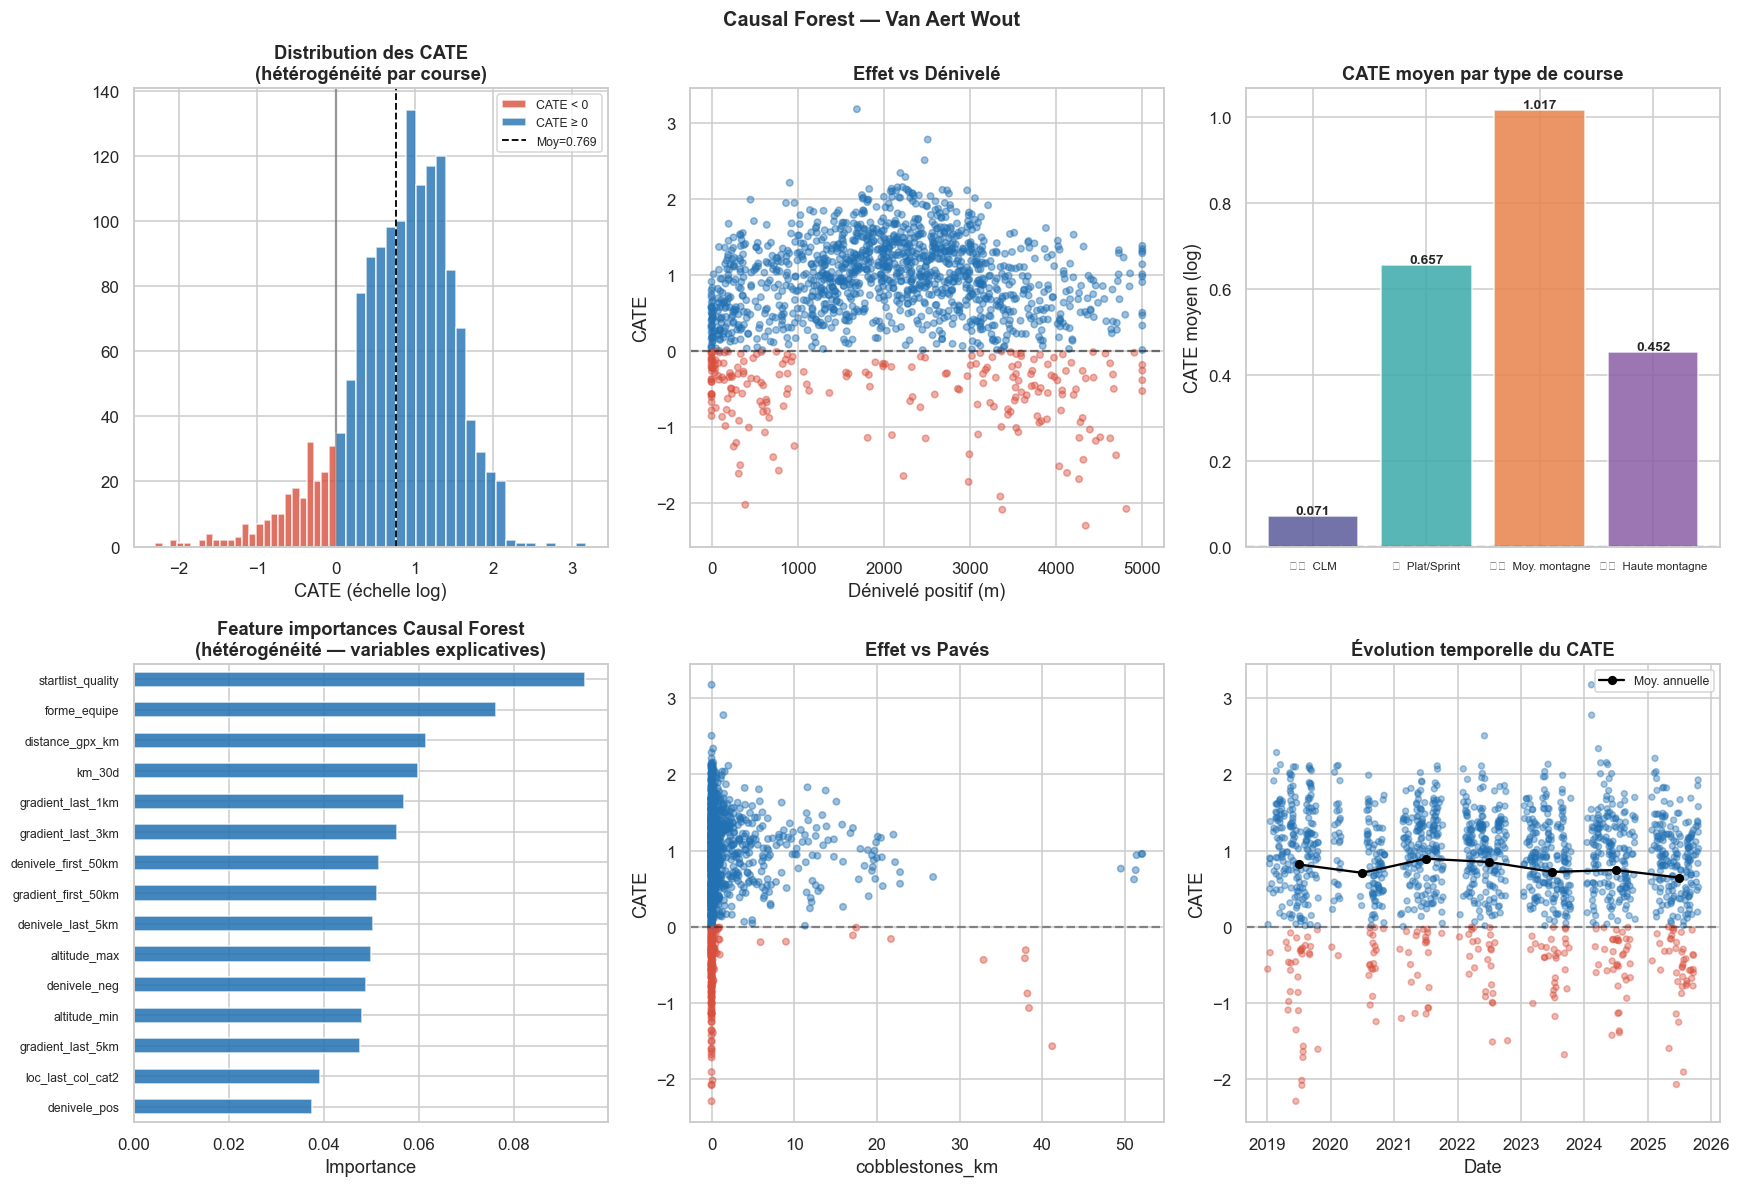

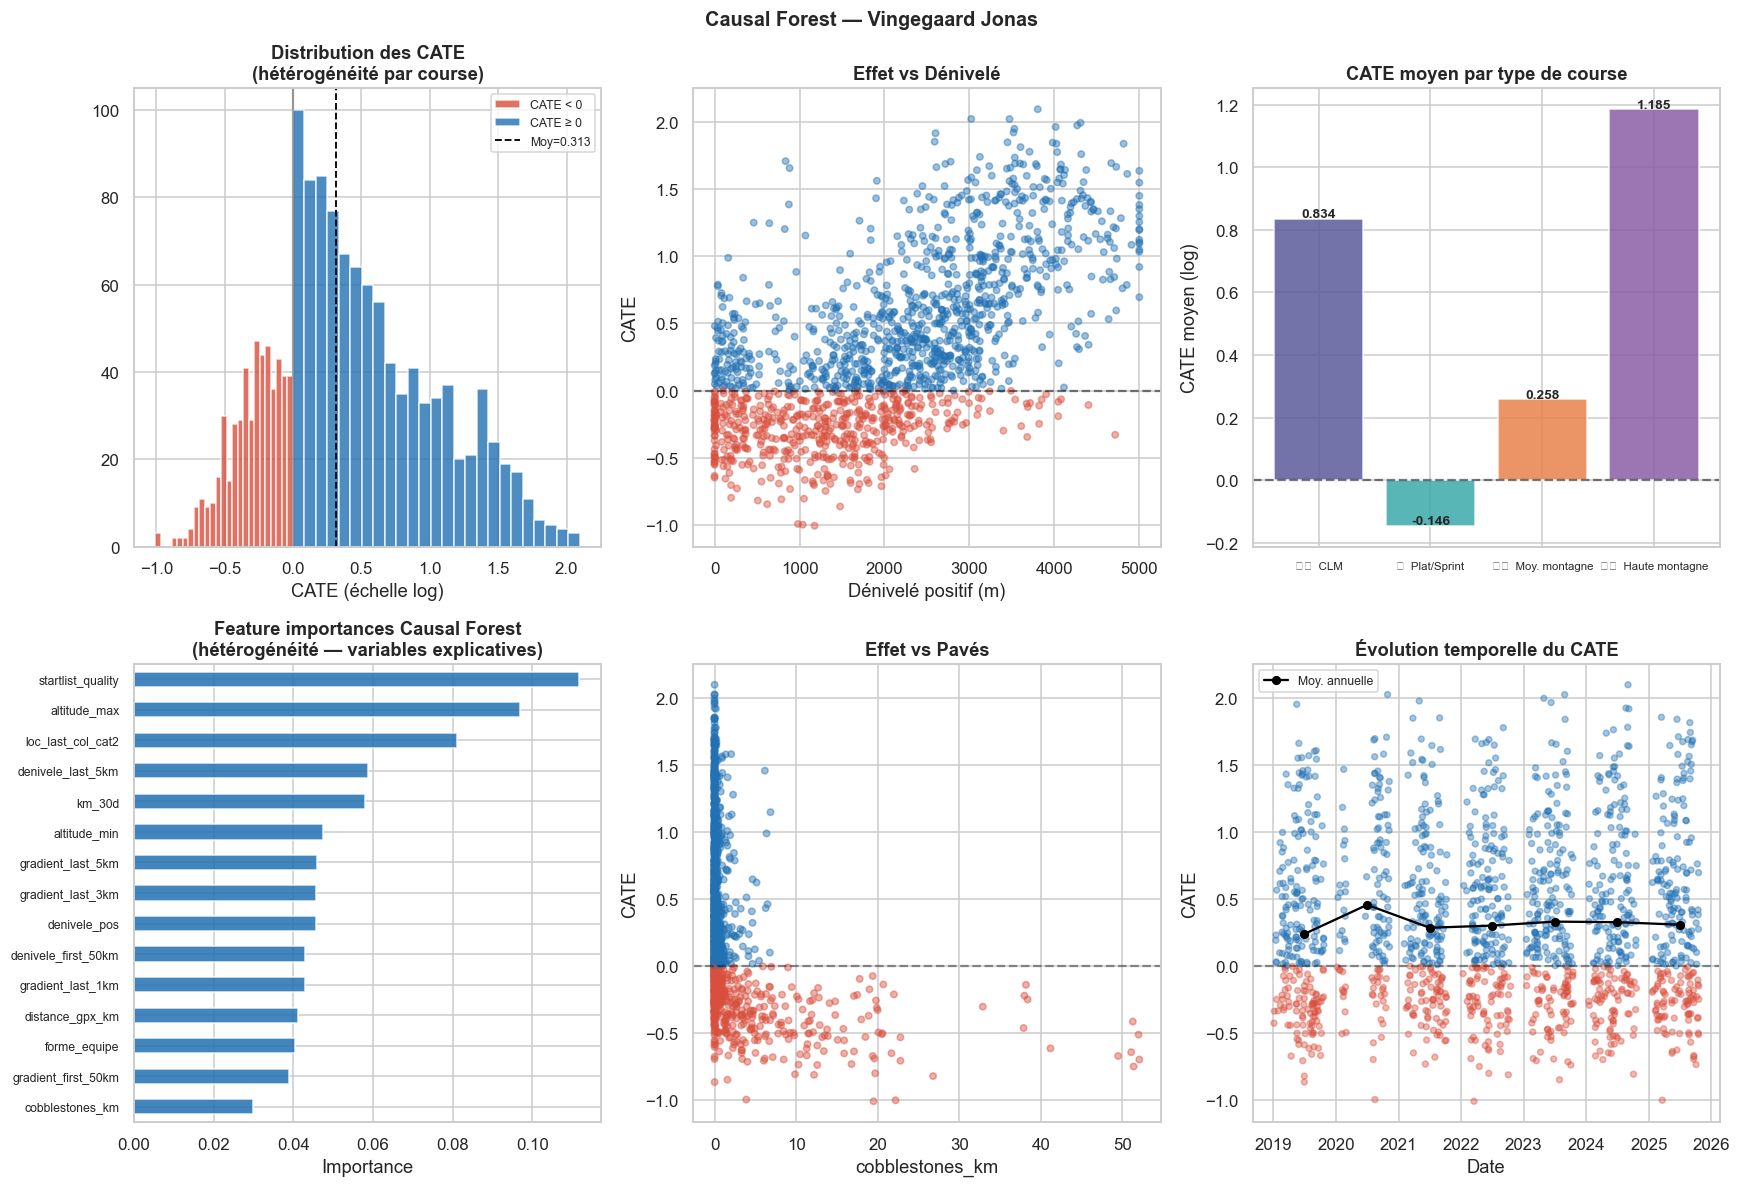

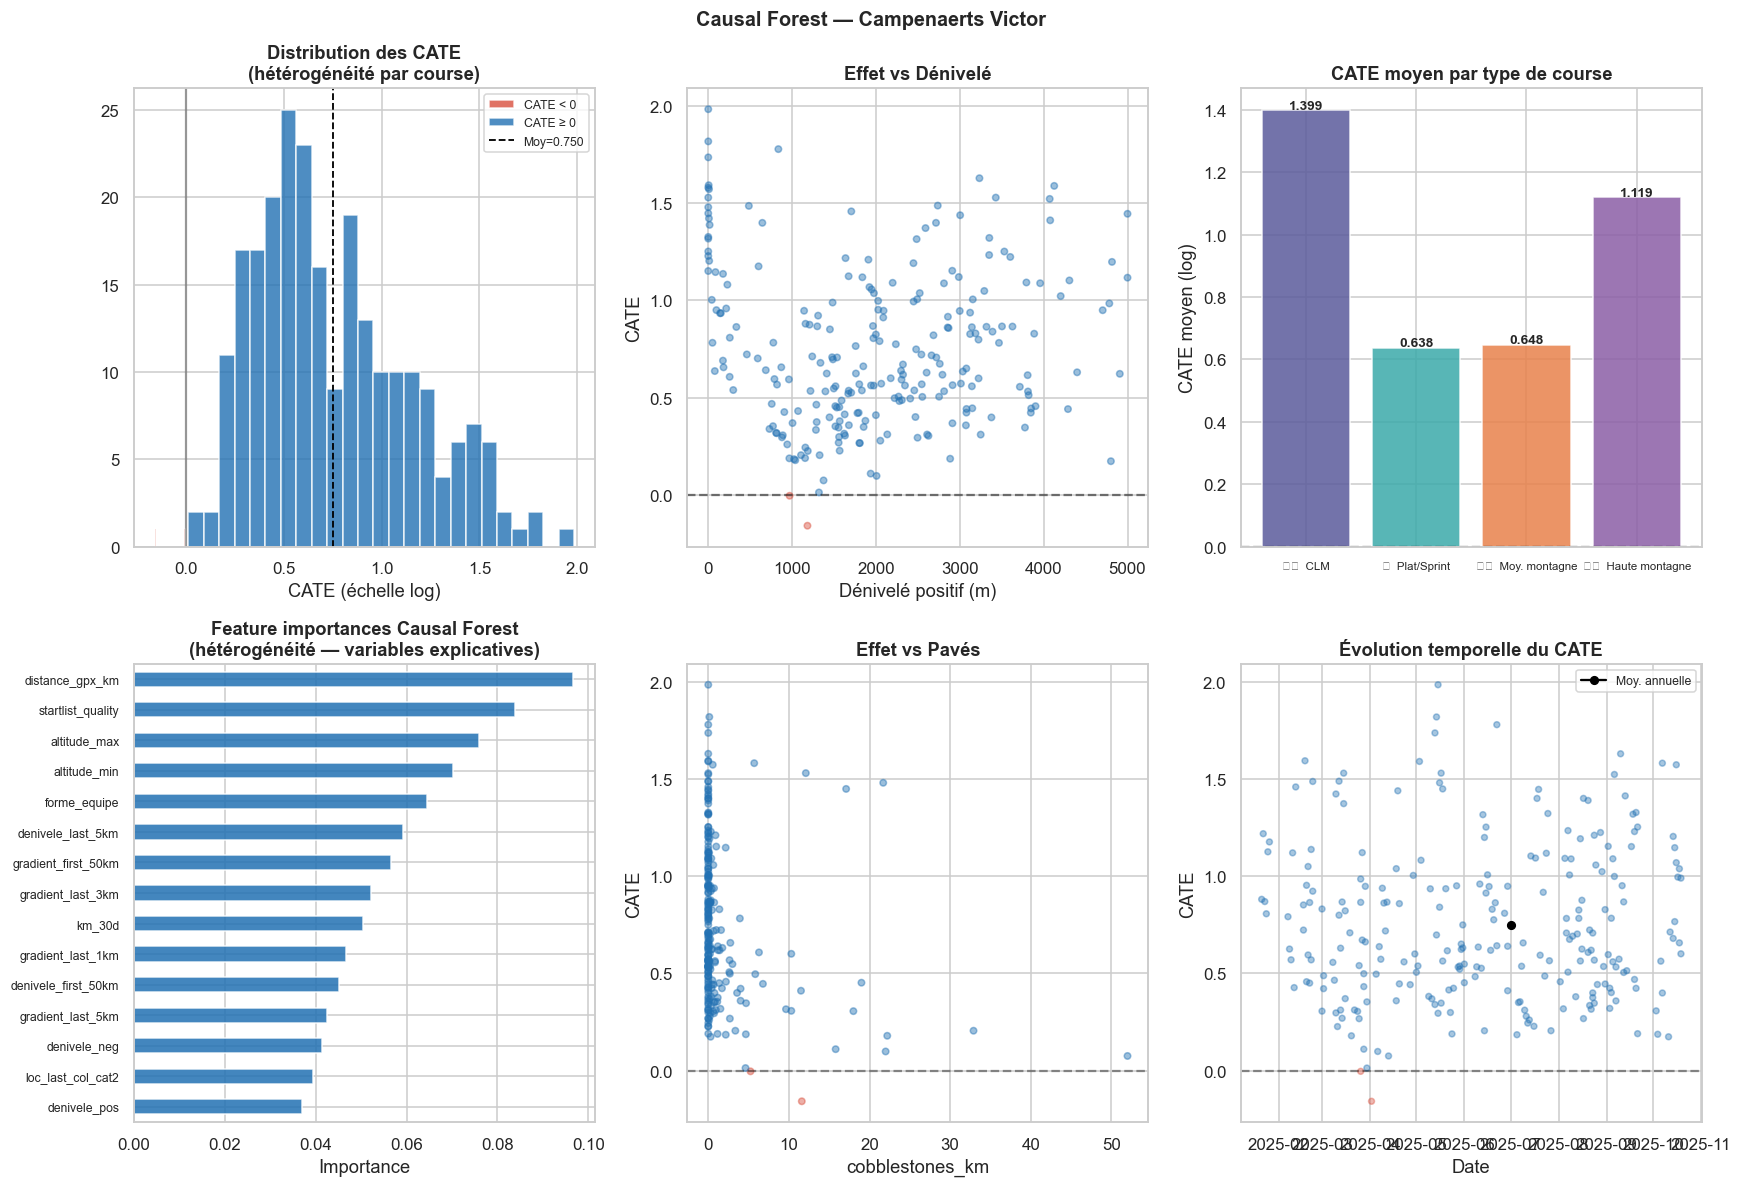

In [15]:
# ── Visualisation Causal Forest — tous les coureurs COUREURS_CF ───────────────
# cf_store contient {rider: (cf_model, cate, df_f_clean, feats_f)} pour chaque coureur
for rider_name, (cf_model_r, cate_r, df_r_clean, feats_r) in cf_store.items():
    if 'cate' not in df_r_clean.columns:
        continue

    fig, axes = plt.subplots(2, 3, figsize=(16, 11))

    # Distribution CATE
    ax = axes[0, 0]
    pos = cate_r[cate_r >= 0]
    neg = cate_r[cate_r <  0]
    ax.hist(neg, bins=25, color=C_RED,  edgecolor='white', alpha=0.8, label='CATE < 0')
    ax.hist(pos, bins=25, color=C_BLUE, edgecolor='white', alpha=0.8, label='CATE ≥ 0')
    ax.axvline(cate_r.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Moy={cate_r.mean():.3f}')
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title('Distribution des CATE\n(hétérogénéité par course)', fontweight='bold')
    ax.set_xlabel('CATE (échelle log)')
    ax.legend(fontsize=8)

    # CATE vs dénivelé
    ax = axes[0, 1]
    if 'denivele_pos' in df_r_clean.columns:
        colors_sc = [C_BLUE if v >= 0 else C_RED for v in cate_r]
        ax.scatter(df_r_clean['denivele_pos'].clip(0, 5000), cate_r,
                   c=colors_sc, alpha=0.45, s=18)
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Dénivelé positif (m)')
        ax.set_ylabel('CATE')
        ax.set_title('Effet vs Dénivelé', fontweight='bold')

    # CATE par stage_cluster
    ax = axes[0, 2]
    if 'stage_cluster_label' in df_r_clean.columns:
        order = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
        cate_cl = df_r_clean.groupby('stage_cluster_label')['cate'].mean()
        cate_cl = cate_cl.reindex([c for c in order if c in cate_cl.index])
        colors_cl = [CLUSTER_COLORS.get(c, C_GRAY) for c in cate_cl.index]
        bars = ax.bar(range(len(cate_cl)), cate_cl.values,
                      color=colors_cl, edgecolor='white', alpha=0.85)
        ax.axhline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(cate_cl)))
        ax.set_xticklabels(cate_cl.index, fontsize=7.5)
        ax.set_ylabel('CATE moyen (log)')
        ax.set_title('CATE moyen par type de course', fontweight='bold')
        for bar, val in zip(bars, cate_cl.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    # Feature importances
    ax = axes[1, 0]
    fi = pd.Series(cf_model_r.feature_importances_, index=feats_r).sort_values(ascending=True).tail(15)
    fi.plot(kind='barh', ax=ax, color=C_BLUE, alpha=0.85, edgecolor='white')
    ax.set_title('Feature importances Causal Forest\n(hétérogénéité — variables explicatives)',
                 fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=8)

    # CATE vs cobblestones
    ax = axes[1, 1]
    if 'cobblestones_km' in df_r_clean.columns:
        colors_co = [C_BLUE if v >= 0 else C_RED for v in cate_r]
        ax.scatter(df_r_clean['cobblestones_km'].clip(0, 60), cate_r,
                   c=colors_co, alpha=0.45, s=18)
        ax.axhline(0, color='black', linestyle='--', alpha=0.4)
        ax.set_xlabel('cobblestones_km')
        ax.set_ylabel('CATE')
        ax.set_title('Effet vs Pavés', fontweight='bold')

    # Timeline CATE
    ax = axes[1, 2]
    if 'date' in df_r_clean.columns:
        df_r_clean = df_r_clean.copy()
        df_r_clean['date'] = pd.to_datetime(df_r_clean['date'])
        colors_tl = [C_BLUE if v >= 0 else C_RED for v in cate_r]
        ax.scatter(df_r_clean['date'], cate_r, c=colors_tl, alpha=0.4, s=15)
        cate_year = df_r_clean.groupby(df_r_clean['date'].dt.year)['cate'].mean()
        ax.plot(pd.to_datetime(cate_year.index.astype(str) + '-07-01'),
                cate_year.values, 'o-', color='black', linewidth=1.5, markersize=5,
                label='Moy. annuelle')
        ax.axhline(0, color='black', linestyle='--', alpha=0.4)
        ax.set_xlabel('Date')
        ax.set_ylabel('CATE')
        ax.set_title('Évolution temporelle du CATE', fontweight='bold')
        ax.legend(fontsize=8)

    plt.suptitle(f'Causal Forest — {rider_name.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [16]:
# ── Vingegaard — CATE × Dénivelé positif (interactif) ───────────────────────
import plotly.express as px

_rider = 'vingegaard_jonas'

if _rider in cf_store:
    _, _cate, _df_clean, _ = cf_store[_rider]
    df_viz = _df_clean[_df_clean['selected'] == 1].copy()
    df_viz['cate'] = _cate[_df_clean['selected'] == 1]
    df_viz['leader'] = df_viz['leader_played'].map({1: 'Leader présent', 0: 'Sans leader'}).fillna('Sans leader')
    df_viz['label'] = (
        df_viz['course'].str.replace('-', ' ').str.title()
        + ' ' + df_viz['year'].astype(int).astype(str)
        + df_viz['stage_num'].apply(lambda s: f' ét.{int(s)}' if pd.notna(s) else '')
    )

    fig = px.scatter(
        df_viz,
        x='denivele_pos',
        y='cate',
        color='leader',
        color_discrete_map={'Leader présent': '#1f77b4', 'Sans leader': '#ff7f0e'},
        hover_name='label',
        hover_data={
            'denivele_pos': ':.0f',
            'cate': ':.3f',
            'n_cols_hc': True,
            'startlist_quality': ':.0f',
            'leader': False,
        },
        labels={
            'denivele_pos': 'Dénivelé positif (m)',
            'cate': 'CATE (effet causal estimé)',
        },
        title=f'Vingegaard — CATE vs Dénivelé positif<br><sup>Chaque point = une course sélectionnée | survoler pour le nom</sup>',
        template='plotly_white',
        width=900, height=550,
    )
    fig.add_hline(y=0, line_dash='dash', line_color='red', opacity=0.4)
    fig.update_traces(marker=dict(size=7, opacity=0.75))
    fig.show()
else:
    print(f'{_rider} absent de cf_store — exécuter la cellule Causal Forest d\'abord')


## 4.7 — Niveau de compétition (startlist_quality)

`startlist_quality` (PCS) mesure le niveau moyen des coureurs présents sur la course.
- **Grand Tour** (TDF/Vuelta/Giro) : ~800–1200
- **Monument** : ~600–900
- **Pro Series** : ~300–600
- **Courses mineures** : < 300

Question : l'effet causal d'un coureur varie-t-il selon la qualité du peloton ?

> **Note données** : `startlist_quality` a seulement **1.2% de NaN** → utilisé directement dans les features DML (imputation médiane pour les rares NaN).

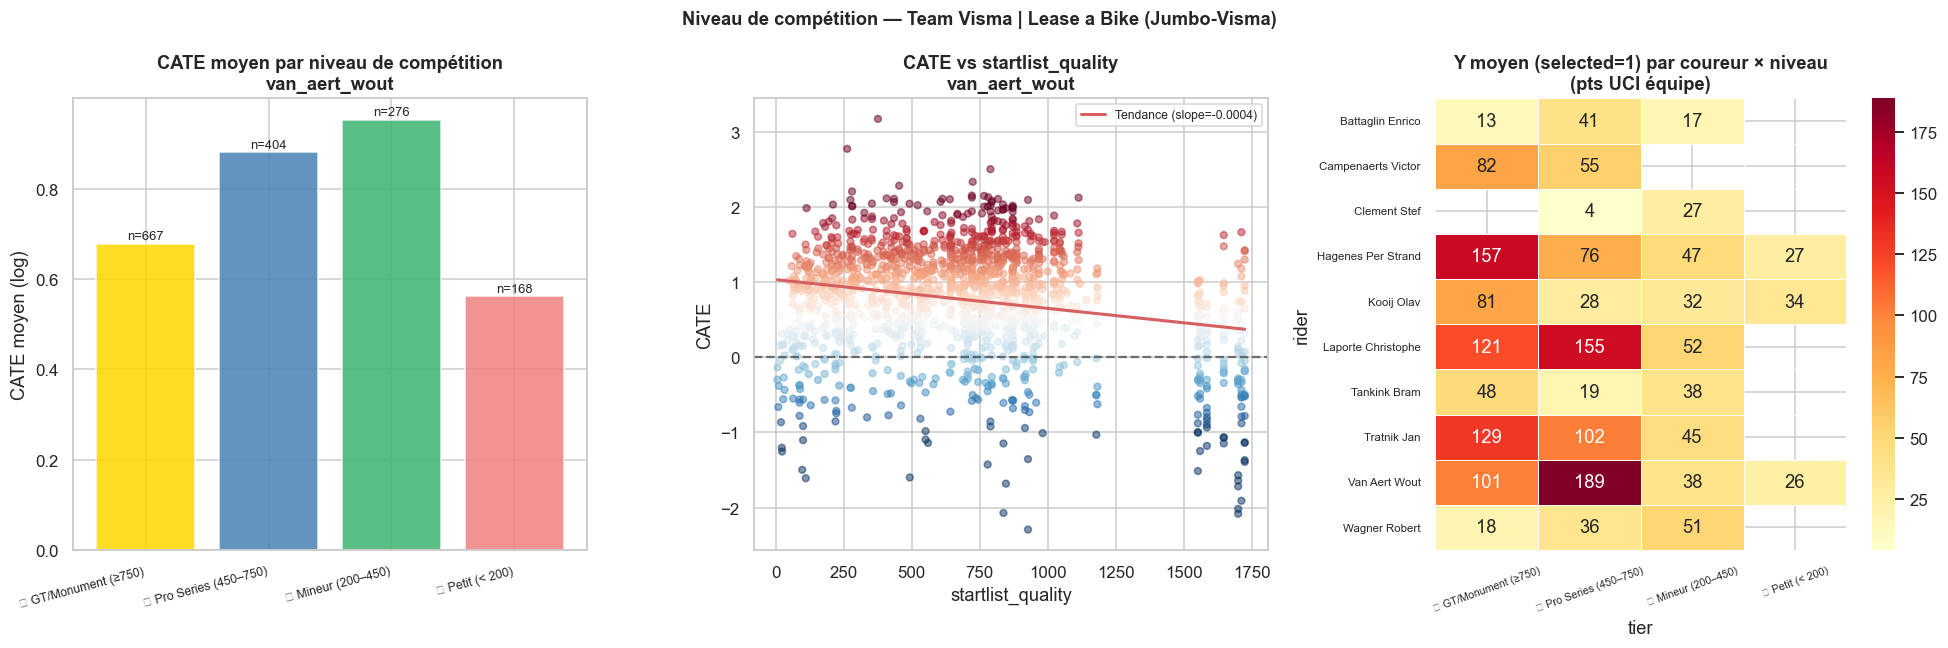

In [17]:
# ── startlist_quality × CATE : analyse par niveau de compétition ─────────────
def sq_tier(sq):
    if pd.isna(sq): return 'Inconnu'
    if sq >= 750:   return '🏆 GT/Monument (≥750)'
    if sq >= 450:   return '🥈 Pro Series (450–750)'
    if sq >= 200:   return '🥉 Mineur (200–450)'
    return           '📋 Petit (< 200)'

TIER_ORDER  = ['🏆 GT/Monument (≥750)', '🥈 Pro Series (450–750)',
               '🥉 Mineur (200–450)',    '📋 Petit (< 200)']
TIER_COLORS = {'🏆 GT/Monument (≥750)': 'gold', '🥈 Pro Series (450–750)': 'steelblue',
               '🥉 Mineur (200–450)': 'mediumseagreen', '📋 Petit (< 200)': 'lightcoral'}

if prep_f is not None and 'cate' in df_f_clean.columns and 'startlist_quality' in df_f_clean.columns:
    df_sq = df_f_clean.copy()
    df_sq['tier'] = df_sq['startlist_quality'].apply(sq_tier)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # CATE par tier (coureur focus)
    ax = axes[0]
    cate_tier = df_sq.groupby('tier')['cate'].mean().reindex(
        [t for t in TIER_ORDER if t in df_sq['tier'].values])
    ax.bar(range(len(cate_tier)), cate_tier.values,
           color=[TIER_COLORS.get(t,'gray') for t in cate_tier.index],
           edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(cate_tier)))
    ax.set_xticklabels(cate_tier.index, rotation=15, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('CATE moyen (log)')
    ax.set_title(f'CATE moyen par niveau de compétition\n{COUREUR_FOCUS}', fontweight='bold')
    for i, (t, v) in enumerate(cate_tier.items()):
        n = (df_sq['tier']==t).sum()
        ax.text(i, v + 0.01, f'n={n}', ha='center', fontsize=8.5)

    # Scatter CATE vs startlist_quality
    ax = axes[1]
    ax.scatter(df_sq['startlist_quality'], df_sq['cate'],
               c=df_sq['cate'], cmap='RdBu_r', alpha=0.5, s=20, vmin=-1, vmax=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('startlist_quality')
    ax.set_ylabel('CATE')
    ax.set_title(f'CATE vs startlist_quality\n{COUREUR_FOCUS}', fontweight='bold')
    sq_valid = df_sq.dropna(subset=['startlist_quality','cate'])
    if len(sq_valid) > 10:
        coef = np.polyfit(sq_valid['startlist_quality'], sq_valid['cate'], 1)
        xline = np.linspace(sq_valid['startlist_quality'].min(),
                            sq_valid['startlist_quality'].max(), 100)
        ax.plot(xline, np.polyval(coef, xline), 'r-', linewidth=2,
                label=f'Tendance (slope={coef[0]:.4f})')
        ax.legend(fontsize=8)

    # Heatmap multi-coureurs : Y moyen par tier
    ax = axes[2]
    rows_sq = []
    # Top 10 coureurs par ATE (df_results trié par défaut)
    top10_riders = df_results.head(min(10, len(df_results)))['rider'].tolist()
    for rn in top10_riders:
        df_r = load_rider(rn, equipe=EQUIPE)
        if df_r is None or 'startlist_quality' not in df_r.columns:
            continue
        df_r['tier'] = df_r['startlist_quality'].apply(sq_tier)
        sel1 = df_r[df_r[TREATMENT]==1]
        for tier in TIER_ORDER:
            s = sel1[sel1['tier']==tier]
            if len(s) >= 5:
                rows_sq.append({'rider': rn, 'tier': tier,
                                'Y_mean': s[OUTCOME].mean(), 'n': len(s)})
    if rows_sq:
        pivot_sq = pd.DataFrame(rows_sq).pivot(index='rider', columns='tier', values='Y_mean')
        pivot_sq = pivot_sq[[c for c in TIER_ORDER if c in pivot_sq.columns]]
        sns.heatmap(pivot_sq.astype(float), annot=True, fmt='.0f',
                    cmap='YlOrRd', ax=ax, linewidths=0.5,
                    yticklabels=[r.replace('_',' ').title() for r in pivot_sq.index])
        ax.set_title('Y moyen (selected=1) par coureur × niveau\n(pts UCI équipe)', fontweight='bold')
        ax.tick_params(axis='x', labelsize=7, rotation=20)
        ax.tick_params(axis='y', labelsize=7.5)

    plt.suptitle(f'Niveau de compétition — {EQUIPE_LABEL}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5.5 — Hétérogénéité apprise : opportunités manquées & sélections à éviter

> *"For some riders, which races they did not participate in where the model thinks they would have scored a lot of points, or races they participated in that the model thinks it would have been better to skip."* — Bram

Le Causal Forest estime un **CATE pour chaque observation** (course × coureur), que le coureur ait été sélectionné ou non. Cela permet d'identifier :

- 🟦 **Opportunités manquées** (`selected=0`, CATE élevé) : le modèle estime que le coureur aurait généré un fort uplift s'il avait été aligné
- 🟥 **Sélections sub-optimales** (`selected=1`, CATE négatif) : le coureur n'a pas contribué positivement à l'équipe sur ces étapes

Ces insights sont le cœur de l'application pratique du modèle causal pour l'optimisation du calendrier.

In [18]:
# ── Opportunités manquées & sélections sub-optimales ─────────────────────────
# COUREURS_HETERO : COUREURS_CF + top significatifs par ATE
_sig_riders = df_results[df_results['significant']].nlargest(8, 'ate_orig')['rider'].tolist()
COUREURS_HETERO = list(dict.fromkeys(
    [r for r in COUREURS_CF if r in RIDERS] +
    [r for r in _sig_riders if r in RIDERS]
))
print(f'Coureurs analysés pour hétérogénéité : {COUREURS_HETERO}')

CONTEXT_COLS = ['date', 'year', 'course', 'stage_num', 'equipe',
                'stage_cluster_label', 'startlist_quality',
                'distance_gpx_km', 'denivele_pos', 'n_cols_hc',
                'gradient_last_1km', 'cobblestones_km', OUTCOME, 'rang']
CATE_THRESHOLD_HIGH = 0.3   # seuil abaissé (0.3 log ≈ +35% pts équipe)
CATE_THRESHOLD_LOW  = 0.0
TOP_N_PER_RIDER     = 2

all_missed, all_wasted = {}, {}

for rider_name in COUREURS_HETERO:
    if rider_name in cf_store:
        _, cate_r, df_clean_r, _ = cf_store[rider_name]
        df_clean_r = df_clean_r.copy()
    else:
        df_r = load_rider(rider_name, equipe=EQUIPE)
        if df_r is None:
            continue
        prep = prepare_features(df_r)
        if prep is None:
            continue
        X_r, T_r, Y_r, df_clean_r, _ = prep
        try:
            _, cate_r = run_causal_forest(X_r, T_r, Y_r, n_estimators=300)
        except Exception as e:
            print(f'⚠️  {rider_name} : {e}')
            continue
        df_clean_r = df_clean_r.copy()
        df_clean_r['cate'] = cate_r

    df_clean_r['rider'] = rider_name
    ctx = [c for c in CONTEXT_COLS if c in df_clean_r.columns]

    # Filtre GT
    if 'course' in df_clean_r.columns and 'year' in df_clean_r.columns:
        gt_key = (df_clean_r[df_clean_r[TREATMENT]==1]
                  .groupby(['course','year'])[TREATMENT].count()
                  .reset_index().rename(columns={TREATMENT:'n_sel_in_race'}))
        gt_key = gt_key[gt_key['n_sel_in_race'] > 14][['course','year']]
        gt_key['_is_gt'] = True
        df_clean_r = df_clean_r.merge(gt_key, on=['course','year'], how='left')
        df_clean_r['_is_gt'] = df_clean_r['_is_gt'].fillna(False)
    else:
        df_clean_r['_is_gt'] = False

    non_gt_t0 = df_clean_r[(df_clean_r[TREATMENT]==0) & (~df_clean_r['_is_gt'])]
    non_gt_t1 = df_clean_r[(df_clean_r[TREATMENT]==1) & (~df_clean_r['_is_gt'])]

    # Top 2 par CATE — indépendamment du seuil (seuil sert juste pour la couleur)
    missed_df = non_gt_t0.nlargest(TOP_N_PER_RIDER, 'cate')[ctx + ['cate','rider']].copy()
    wasted_df = non_gt_t1.nsmallest(TOP_N_PER_RIDER, 'cate')[ctx + ['cate','rider']].copy()

    all_missed[rider_name] = missed_df
    all_wasted[rider_name] = wasted_df

    n_t0 = len(non_gt_t0)
    n_above = (non_gt_t0['cate'] >= CATE_THRESHOLD_HIGH).sum()
    print(f'{rider_name}: {n_t0} étapes non-GT T=0 | {n_above} avec CATE >= {CATE_THRESHOLD_HIGH}')

show_cols = [c for c in ['rider','course','year','stage_cluster_label',
                          'startlist_quality','denivele_pos','cate']
             if len(all_missed) > 0 and c in next(iter(all_missed.values())).columns]
print()
for rn in COUREURS_HETERO:
    if rn in all_missed:
        print(f'--- {rn} ---')
        m = all_missed[rn]
        w = all_wasted.get(rn, pd.DataFrame())
        if len(m) > 0:
            print('  Opportunités manquées :')
            print(m[[c for c in show_cols if c in m.columns]].to_string(index=False))
        if len(w) > 0:
            print('  Sélections sub-optimales :')
            print(w[[c for c in show_cols if c in w.columns]].to_string(index=False))
        print()


Coureurs analysés pour hétérogénéité : ['van_aert_wout', 'vingegaard_jonas', 'campenaerts_victor', 'laporte_christophe', 'tankink_bram', 'hagenes_per_strand', 'kooij_olav', 'roglič_primož', 'hofstede_lennard']
van_aert_wout: 1189 étapes non-GT T=0 | 969 avec CATE >= 0.3
vingegaard_jonas: 1174 étapes non-GT T=0 | 471 avec CATE >= 0.3
campenaerts_victor: 177 étapes non-GT T=0 | 162 avec CATE >= 0.3
laporte_christophe: 765 étapes non-GT T=0 | 678 avec CATE >= 0.3
tankink_bram: 205 étapes non-GT T=0 | 171 avec CATE >= 0.3
hagenes_per_strand: 833 étapes non-GT T=0 | 721 avec CATE >= 0.3
kooij_olav: 1009 étapes non-GT T=0 | 760 avec CATE >= 0.3
roglič_primož: 942 étapes non-GT T=0 | 508 avec CATE >= 0.3
hofstede_lennard: 828 étapes non-GT T=0 | 475 avec CATE >= 0.3

--- van_aert_wout ---
  Opportunités manquées :
        rider            course  year stage_cluster_label  startlist_quality  denivele_pos  cate
van_aert_wout volta-a-catalunya  2024   ⛰️  Moy. montagne            724.000    

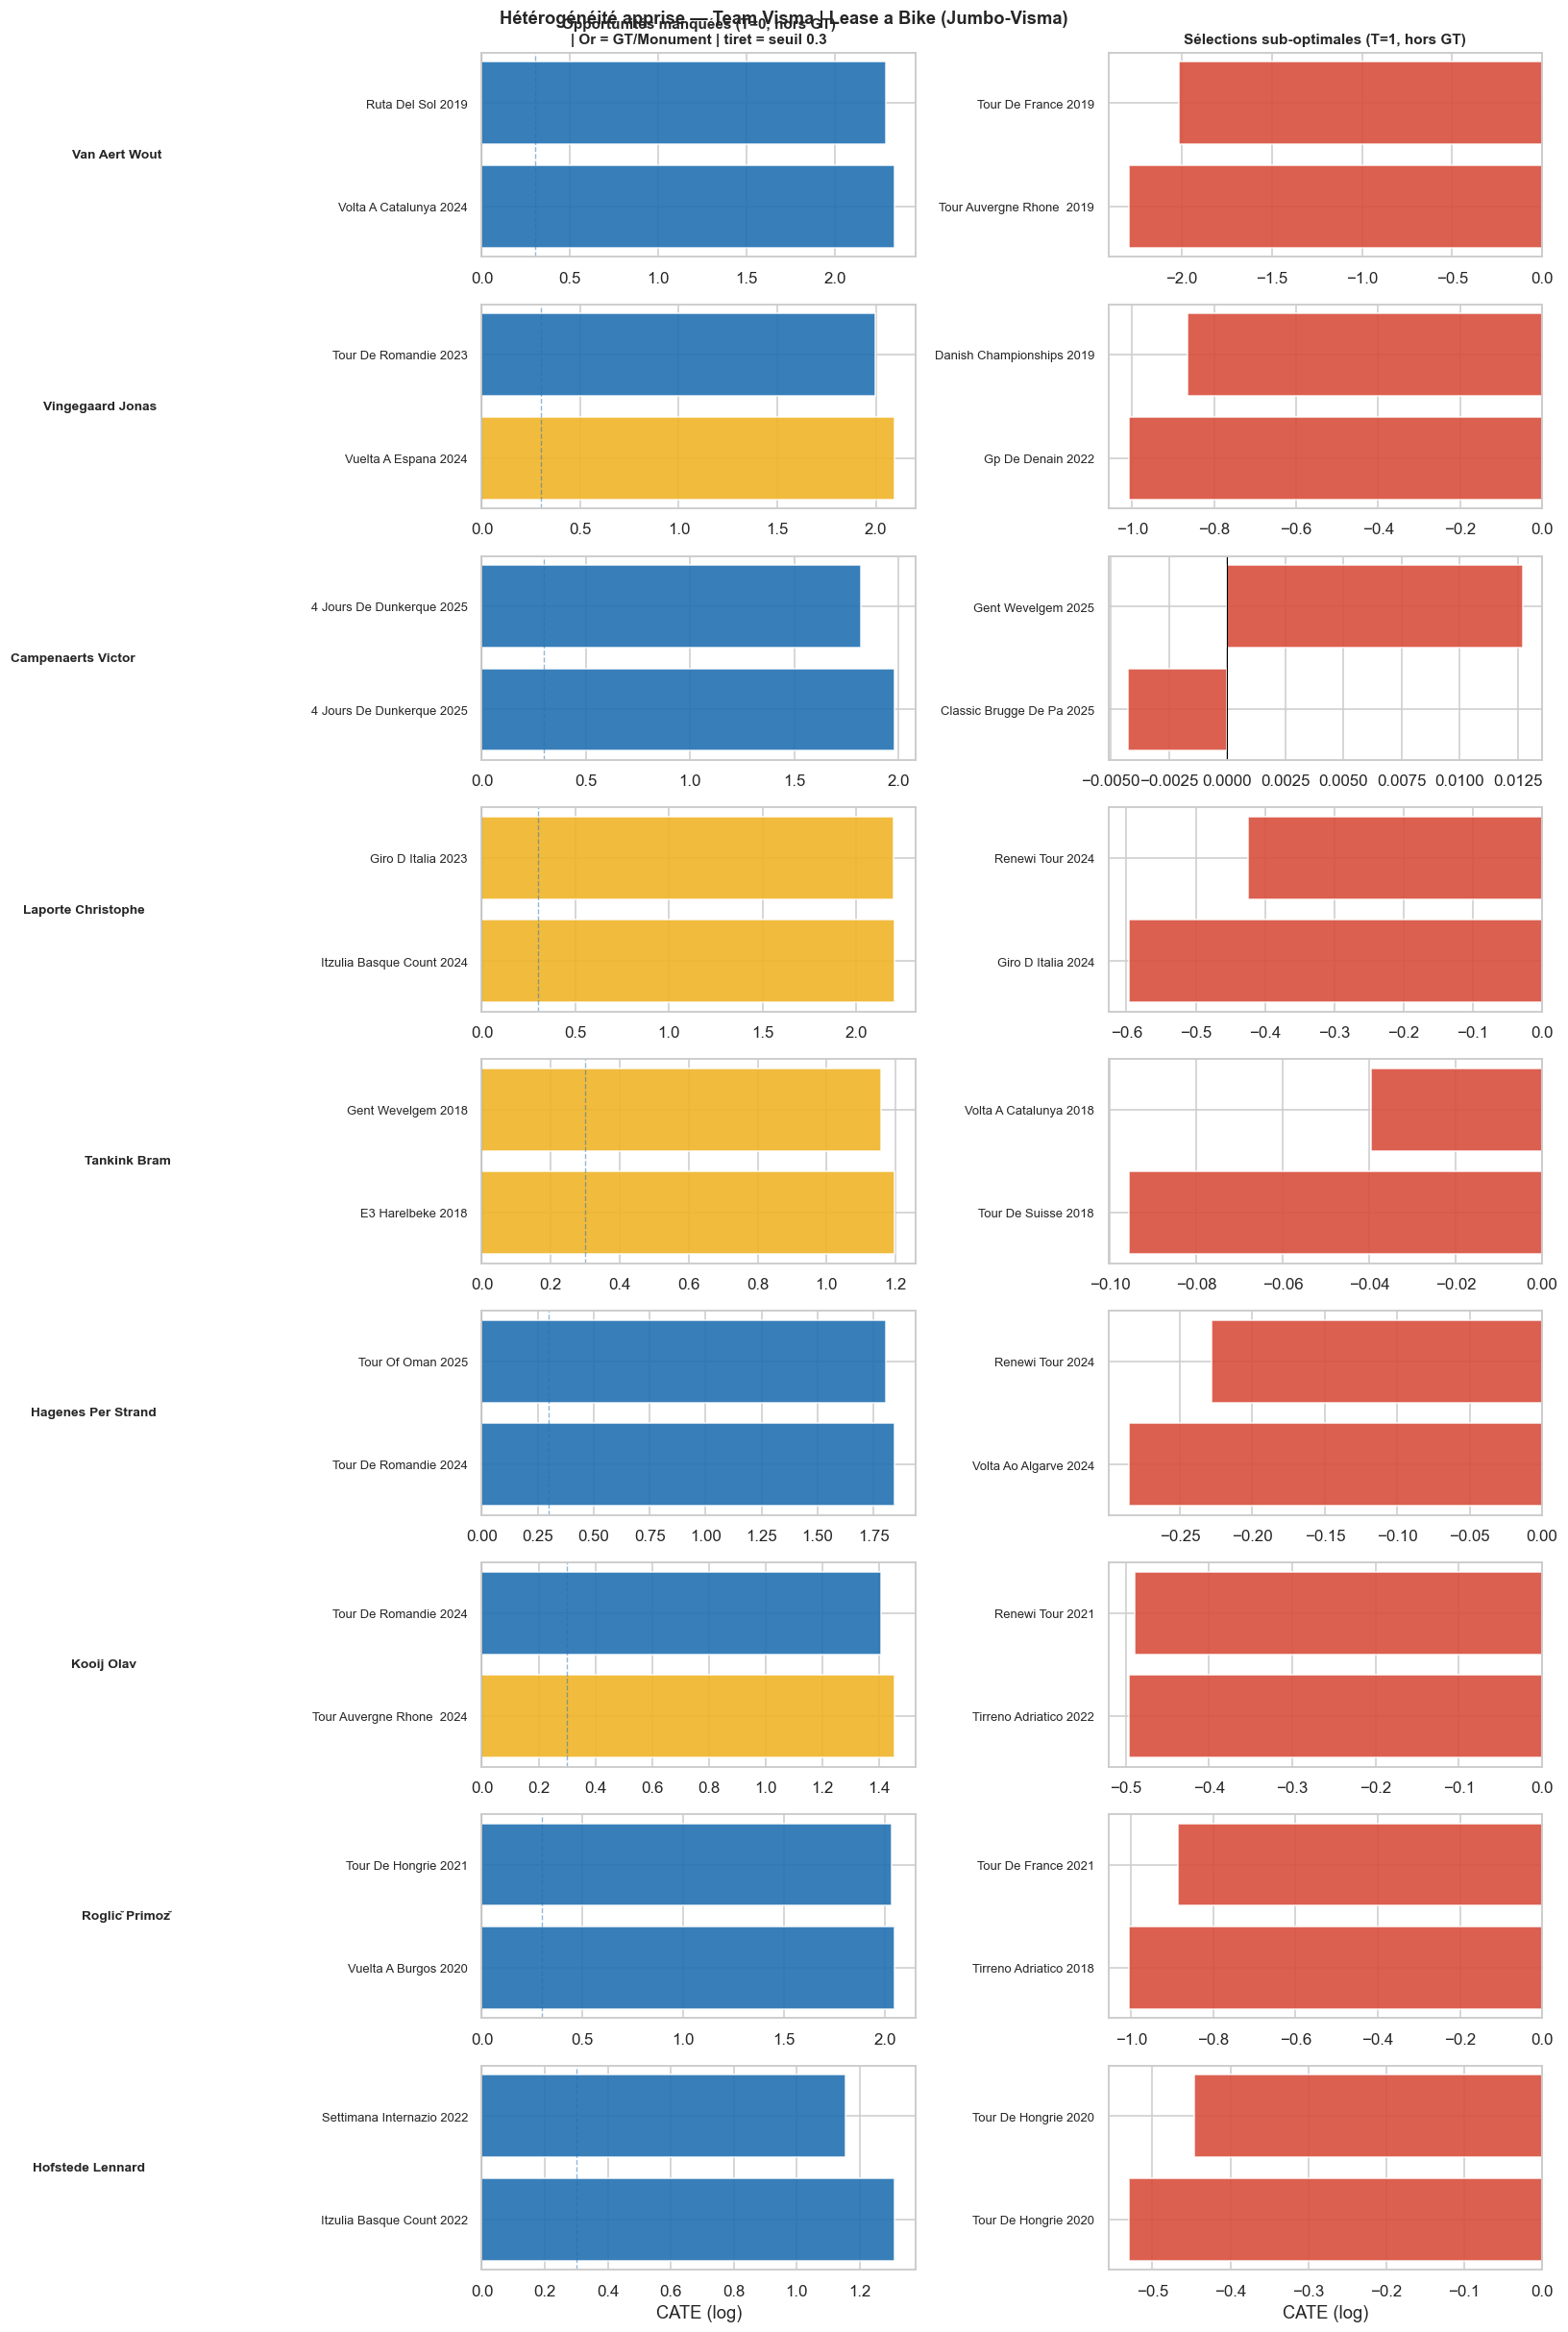

In [19]:
# ── Visualisation hétérogénéité — grille par coureur ─────────────────────────
if all_missed or all_wasted:
    riders_plot = [r for r in COUREURS_HETERO if r in all_missed or r in all_wasted]
    n_riders = len(riders_plot)
    if n_riders == 0:
        print('Aucun résultat à afficher')
    else:
        fig, axes = plt.subplots(n_riders, 2,
                                 figsize=(15, max(3, n_riders * 2.5)),
                                 squeeze=False)

        for row_i, rn in enumerate(riders_plot):
            rider_label = rn.replace('_', ' ').title()
            missed_r = all_missed.get(rn, pd.DataFrame())
            wasted_r = all_wasted.get(rn, pd.DataFrame())

            # ── Colonne gauche : opportunités manquées ────────────────
            ax = axes[row_i, 0]
            if len(missed_r) > 0:
                labels_m = [str(row.get('course','?'))[:20].replace('-',' ').title()
                            + ' ' + str(int(row['year'])) if pd.notna(row.get('year')) else ''
                            for _, row in missed_r.iterrows()]
                cate_vals = missed_r['cate'].values
                above = cate_vals >= CATE_THRESHOLD_HIGH
                bar_cols = ['#F0B429' if sq >= 750 else (C_BLUE if a else C_TEAL)
                            for sq, a in zip(
                                missed_r.get('startlist_quality', pd.Series([0]*len(missed_r))).fillna(0),
                                above)]
                ax.barh(range(len(missed_r)), cate_vals, color=bar_cols,
                        edgecolor='white', alpha=0.9)
                ax.set_yticks(range(len(missed_r)))
                ax.set_yticklabels(labels_m, fontsize=8.5)
                ax.axvline(CATE_THRESHOLD_HIGH, color=C_BLUE, linestyle='--',
                           alpha=0.5, linewidth=0.9)
                ax.axvline(0, color='black', linewidth=0.7)
                ax.set_xlabel('CATE (log)' if row_i == n_riders-1 else '')
            else:
                ax.text(0.5, 0.5, 'Aucune (toujours bien\nsélectionné)',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=9, color=C_GRAY)
                ax.axis('off')

            ax.set_ylabel(rider_label, fontsize=9, fontweight='bold',
                          rotation=0, ha='right', va='center', labelpad=120)
            if row_i == 0:
                ax.set_title('Opportunités manquées (T=0, hors GT)\n| Or = GT/Monument | tiret = seuil 0.3',
                             fontweight='bold', fontsize=10)

            # ── Colonne droite : sélections sub-optimales ────────────
            ax = axes[row_i, 1]
            if len(wasted_r) > 0:
                labels_w = [str(row.get('course','?'))[:20].replace('-',' ').title()
                            + ' ' + str(int(row['year'])) if pd.notna(row.get('year')) else ''
                            for _, row in wasted_r.iterrows()]
                ax.barh(range(len(wasted_r)), wasted_r['cate'].values,
                        color=C_RED, edgecolor='white', alpha=0.9)
                ax.set_yticks(range(len(wasted_r)))
                ax.set_yticklabels(labels_w, fontsize=8.5)
                ax.axvline(0, color='black', linewidth=0.7)
                ax.set_xlabel('CATE (log)' if row_i == n_riders-1 else '')
            else:
                ax.text(0.5, 0.5, 'Aucune sélection\nnégative identifiée',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=9, color=C_GRAY)
                ax.axis('off')

            if row_i == 0:
                ax.set_title('Sélections sub-optimales (T=1, hors GT)',
                             fontweight='bold', fontsize=10)

        plt.suptitle(f'Hétérogénéité apprise — {EQUIPE_LABEL}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


## 6. Validation & Tests de robustesse

### 6.1 Placebo test
Si notre modèle est correct, il **ne devrait pas détecter d'effet** pour un coureur fictif (traitement aléatoire). On perturbe T aléatoirement pour vérifier que l'ATE s'annule.

### 6.2 Qualité des modèles nuisance
Le DML est valide seulement si les modèles nuisance capturent bien les confondants. On vérifie les R².

### 6.3 Résidus
On vérifie que les résidus `T̃` et `Ỹ` ont bien les propriétés attendues (non corrélés avec X).

Placebo test : on perturbe T aléatoirement et on relance le DML
→ Attendu : ATE placebo ≈ 0 et IC contient 0



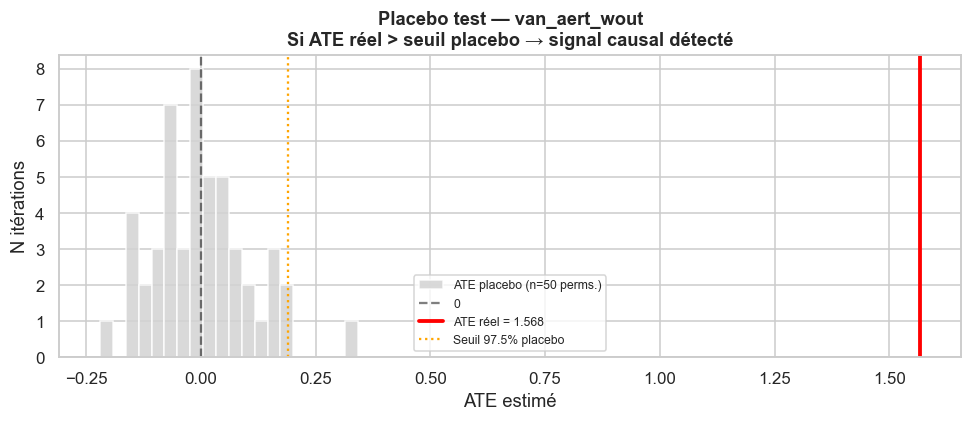

ATE placebo moyen   : 0.0031  (attendu ≈ 0)
ATE placebo p97.5   : 0.1900
ATE réel            : 1.5679
→ ✅ ATE réel > seuil placebo : signal causal plausible


In [20]:
# ── Placebo test ─────────────────────────────────────────────────────────────
# Initialise X_f/T_f/Y_f depuis cf_store si pas encore définis
if COUREUR_FOCUS and COUREUR_FOCUS in cf_store:
    _, _, _df_f, _feats_f = cf_store[COUREUR_FOCUS]
    _prep_f = prepare_features(load_rider(COUREUR_FOCUS, equipe=EQUIPE))
    if _prep_f is not None:
        X_f, T_f, Y_f, _, _ = _prep_f
        prep_f = _prep_f
    else:
        prep_f = None
else:
    prep_f = None

if prep_f is not None:
    print('Placebo test : on perturbe T aléatoirement et on relance le DML')
    print('→ Attendu : ATE placebo ≈ 0 et IC contient 0\n')

    rng_pl = np.random.default_rng(99)
    n_placebo = 50
    placebo_ates = []

    for i in range(n_placebo):
        T_fake = rng_pl.permutation(T_f)  # T aléatoire
        res_pl = run_dml(X_f, T_fake, Y_f, n_boot=100)
        if res_pl:
            placebo_ates.append(res_pl['ate_orig'])

    # ATE réel
    res_real = run_dml(X_f, T_f, Y_f)
    ate_real = res_real['ate_orig'] if res_real else 0

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(placebo_ates, bins=20, color='lightgray', edgecolor='white',
            alpha=0.85, label=f'ATE placebo (n={len(placebo_ates)} perms.)')
    ax.axvline(0,        color='black', linestyle='--', alpha=0.5, label='0')
    ax.axvline(ate_real, color='red',   linewidth=2.5,
               label=f'ATE réel = {ate_real:.3f}')
    ax.axvline(np.percentile(placebo_ates, 97.5), color='orange',
               linestyle=':', label='Seuil 97.5% placebo')
    ax.set_xlabel('ATE estimé')
    ax.set_ylabel('N itérations')
    ax.set_title(f'Placebo test — {COUREUR_FOCUS}\n'
                 f'Si ATE réel > seuil placebo → signal causal détecté', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    placebo_mean = np.mean(placebo_ates)
    placebo_p97 = np.percentile(placebo_ates, 97.5)
    print(f'ATE placebo moyen   : {placebo_mean:.4f}  (attendu ≈ 0)')
    print(f'ATE placebo p97.5   : {placebo_p97:.4f}')
    print(f'ATE réel            : {ate_real:.4f}')
    if ate_real > placebo_p97:
        print(f'→ ✅ ATE réel > seuil placebo : signal causal plausible')
    else:
        print(f'→ ⚠️  ATE réel ≤ seuil placebo : effet non distinguable du bruit')

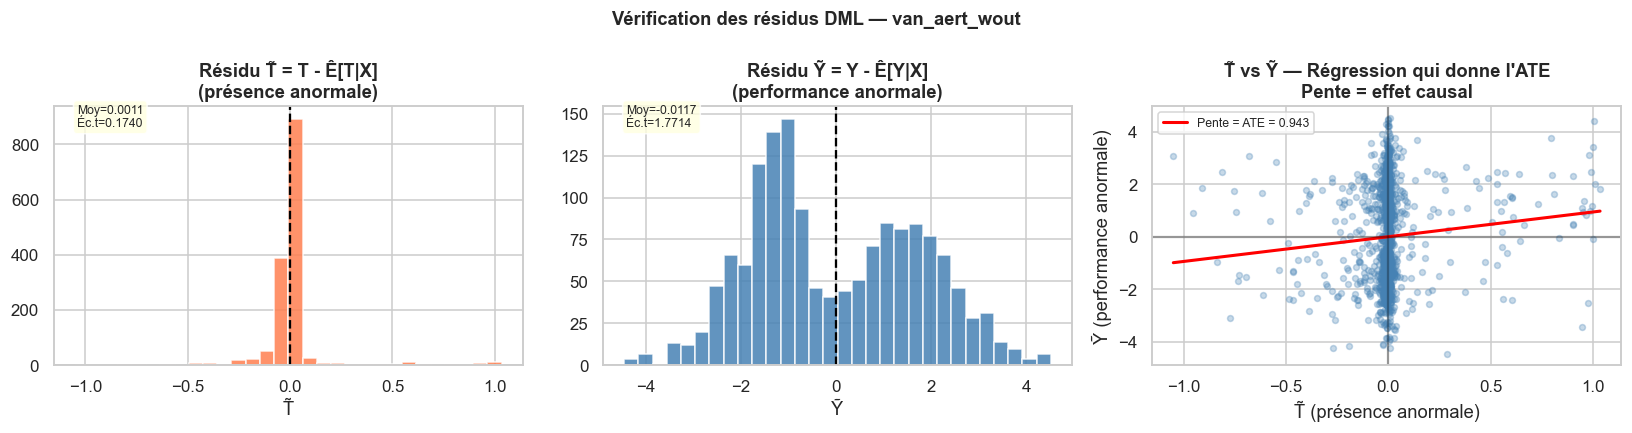

In [21]:
# ── Vérification des résidus ─────────────────────────────────────────────────
if prep_f is not None and res_real:
    T_resid = res_real['T_resid']
    Y_resid = res_real['Y_resid']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Résidus T̃ — distribution
    ax = axes[0]
    ax.hist(T_resid, bins=30, color='coral', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title('Résidu T̃ = T - Ê[T|X]\n(présence anormale)', fontweight='bold')
    ax.set_xlabel('T̃')
    ax.text(0.05, 0.92, f'Moy={T_resid.mean():.4f}\nÉc.t={T_resid.std():.4f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Résidus Ỹ — distribution
    ax = axes[1]
    ax.hist(Y_resid, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title('Résidu Ỹ = Y - Ê[Y|X]\n(performance anormale)', fontweight='bold')
    ax.set_xlabel('Ỹ')
    ax.text(0.05, 0.92, f'Moy={Y_resid.mean():.4f}\nÉc.t={Y_resid.std():.4f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # T̃ vs Ỹ — la régression qui donne l'ATE
    ax = axes[2]
    ax.scatter(T_resid, Y_resid, alpha=0.3, s=15, color='steelblue')
    # Droite de régression
    slope = np.cov(Y_resid, T_resid)[0,1] / (np.var(T_resid) + 1e-10)
    x_line = np.linspace(T_resid.min(), T_resid.max(), 100)
    ax.plot(x_line, slope * x_line, color='red', linewidth=2, label=f'Pente = ATE = {slope:.3f}')
    ax.axhline(0, color='black', alpha=0.3)
    ax.axvline(0, color='black', alpha=0.3)
    ax.set_xlabel('T̃ (présence anormale)')
    ax.set_ylabel('Ỹ (performance anormale)')
    ax.set_title('T̃ vs Ỹ — Régression qui donne l\'ATE\nPente = effet causal', fontweight='bold')
    ax.legend(fontsize=8)

    plt.suptitle(f'Vérification des résidus DML — {COUREUR_FOCUS}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Application — Recommandation de calendrier

On utilise les CATE estimés pour répondre à la question pratique :
> *Pour chaque type de course à venir, quel coureur devrait-on inclure dans l'équipe ?*

On agrège les CATE par `stage_cluster` pour construire un **profil de contribution** par coureur × type de course.

In [22]:
# ── Profil CATE par coureur × cluster ───────────────────────────────────────
print(f'Profil de contribution par type de course — {EQUIPE_LABEL}\n')

profiles = []
order_cl = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']

for rider_name in RIDERS[:min(15, len(RIDERS))]:
    df_r = load_rider(rider_name, equipe=EQUIPE)
    if df_r is None:
        continue
    prep = prepare_features(df_r)
    if prep is None:
        continue
    X_r, T_r, Y_r, df_clean_r, feats_r = prep
    if T_r.sum() < 5:
        continue

    try:
        _, cate_r = run_causal_forest(X_r, T_r, Y_r, n_estimators=200)
        df_clean_r['cate'] = cate_r

        if 'stage_cluster_label' in df_clean_r.columns:
            cate_cl = df_clean_r.groupby('stage_cluster_label')['cate'].mean()
            row = {'rider': rider_name}
            for cl in order_cl:
                row[cl] = cate_cl.get(cl, np.nan)
            profiles.append(row)
            print(f'  ✅ {rider_name}')
    except Exception as e:
        print(f'  ⚠️  {rider_name} : {e}')

if profiles:
    df_profiles = pd.DataFrame(profiles).set_index('rider')
    print(f'\nProfils calculés pour {len(df_profiles)} coureurs')

Profil de contribution par type de course — Team Visma | Lease a Bike (Jumbo-Visma)

  ✅ affini_edoardo
  ✅ battaglin_enrico
  ✅ behrens_niklas
  ✅ bennett_george
  ✅ benoot_tiesj
  ✅ boom_lars
  ✅ bouwman_koen
  ✅ boven_lars
  ✅ brennan_matthew
  ✅ campenaerts_victor
  ✅ clement_stef
  ✅ de_plus_laurens
  ✅ de_tier_floris
  ✅ dekker_david
  ✅ dennis_rohan

Profils calculés pour 15 coureurs


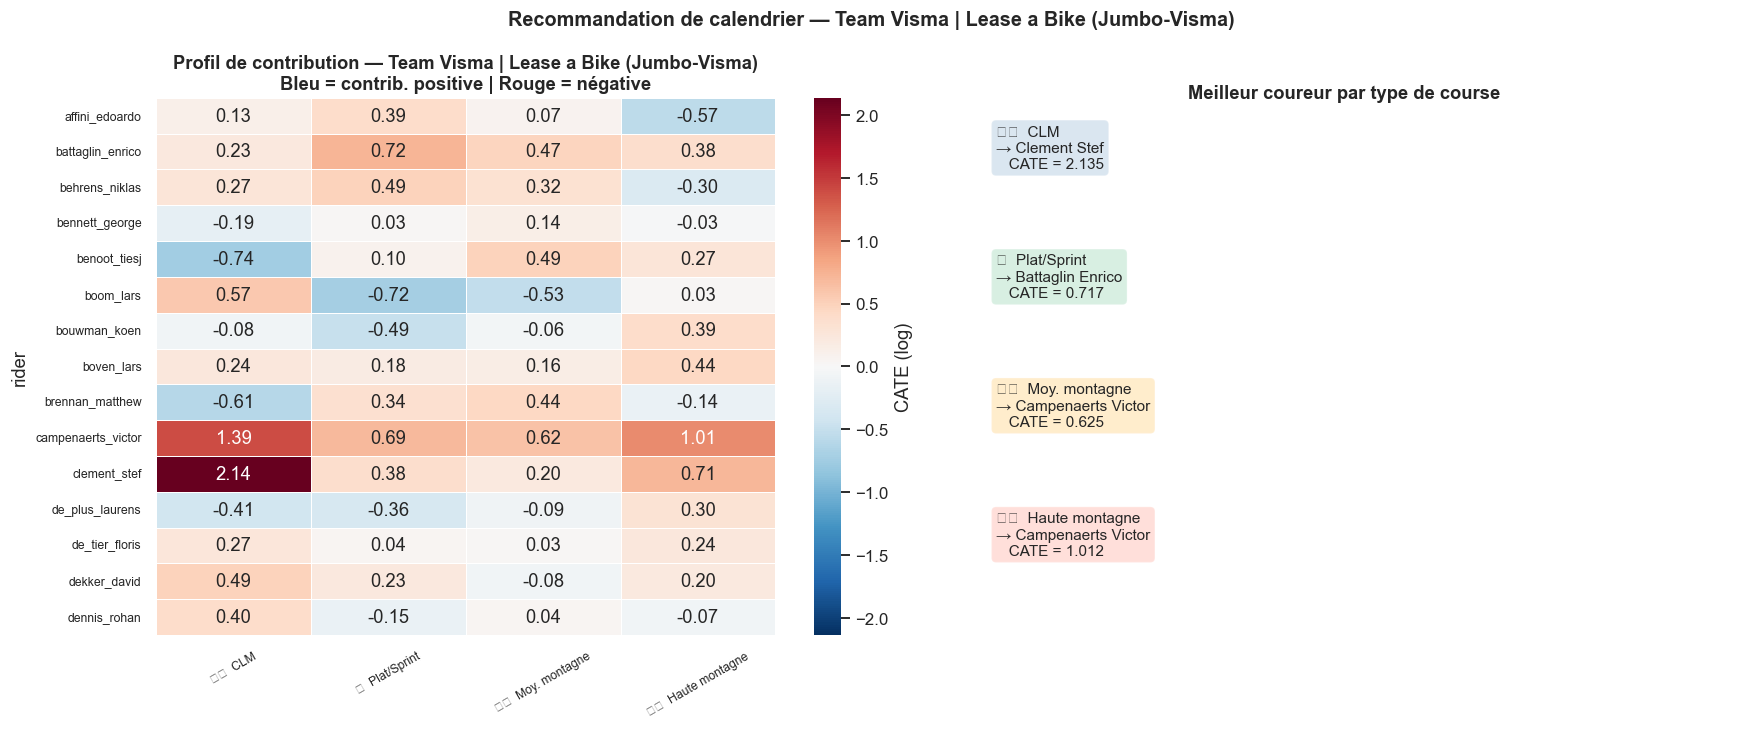


Tableau complet des profils :
                    ⏱️  CLM  🟢  Plat/Sprint  ⛰️  Moy. montagne  🏔️  Haute montagne
rider                                                                             
affini_edoardo        0.125           0.392              0.070              -0.566
battaglin_enrico      0.229           0.717              0.470               0.383
behrens_niklas        0.270           0.489              0.322              -0.301
bennett_george       -0.190           0.029              0.137              -0.031
benoot_tiesj         -0.735           0.100              0.493               0.268
boom_lars             0.574          -0.721             -0.532               0.027
bouwman_koen         -0.079          -0.488             -0.055               0.395
boven_lars            0.236           0.178              0.158               0.441
brennan_matthew      -0.614           0.335              0.438              -0.145
campenaerts_victor    1.392           0.689             

In [23]:
# ── Heatmap des profils ──────────────────────────────────────────────────────
if 'df_profiles' in dir() and len(df_profiles) > 0:
    df_viz = df_profiles[[c for c in order_cl if c in df_profiles.columns]].dropna(how='all')

    if len(df_viz) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_viz)*0.45)))

        # Heatmap CATE
        ax = axes[0]
        vmax = df_viz.abs().max().max()
        sns.heatmap(
            df_viz.astype(float),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-vmax, vmax=vmax,
            linewidths=0.5, cbar_kws={'label': 'CATE (log)'}
        )
        ax.set_title(f'Profil de contribution — {EQUIPE_LABEL}\n'
                     'Bleu = contrib. positive | Rouge = négative', fontweight='bold')
        ax.tick_params(axis='x', labelsize=8, rotation=30)
        ax.tick_params(axis='y', labelsize=8)

        # Meilleur coureur par type de course
        ax = axes[1]
        best     = {cl: df_viz[cl].idxmax() for cl in df_viz.columns if not df_viz[cl].isna().all()}
        best_val = {cl: df_viz[cl].max()    for cl in df_viz.columns if not df_viz[cl].isna().all()}

        colors_cl = {
            '⏱️  CLM'           : 'steelblue',
            '🟢  Plat/Sprint'   : 'mediumseagreen',
            '⛰️  Moy. montagne' : 'orange',
            '🏔️  Haute montagne': 'tomato',
        }
        ax.axis('off')
        y = 0.95
        ax.text(0.5, 1.0, 'Meilleur coureur par type de course',
                transform=ax.transAxes, ha='center', fontsize=12, fontweight='bold')
        for cl, rider_best in best.items():
            col = colors_cl.get(cl, 'gray')
            ax.text(0.05, y,
                    f'{cl}\n'
                    f'→ {rider_best.replace("_"," ").title()}\n'
                    f'   CATE = {best_val[cl]:.3f}',
                    transform=ax.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor=col, alpha=0.2),
                    verticalalignment='top')
            y -= 0.24

        plt.suptitle(f'Recommandation de calendrier — {EQUIPE_LABEL}',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\nTableau complet des profils :')
        print(df_viz.round(3).to_string())

## Conclusion

### Ce qu'on a estimé

| Méthode | Question répondue | Output |
|---------|------------------|--------|
| **DML** | En moyenne, combien de pts UCI en plus/moins gagne l'équipe en incluant ce coureur ? | ATE + IC 95% par coureur |
| **Causal Forest** | Sur quel type de course ce coureur contribue-t-il le plus ? | CATE par course |
| **Recommandation** | Quel coureur envoyer sur quelle course pour maximiser les pts ? | Profil par cluster |

### Hypothèses et limites

1. **Unconfoundedness** : on suppose que les features X (parcours, forme, charge) capturent tous les confondants. Des confondants non observés (blessures, objectifs tactiques) pourraient biaiser les estimations.

2. **SUTVA** : l'effet d'inclure un coureur ne dépend pas des autres coureurs sélectionnés (hypothèse simplificatrice).

3. **Variation suffisante** dans T : le DML nécessite une variation dans `selected` par coureur. Les coureurs avec très peu de sélections ont des IC larges.

### Prochaines étapes
- Étendre à toutes les équipes World Tour
- Intégrer les interactions entre coureurs (ex. leader + domestique ensemble)
- Recommandation de roster optimale sous contraintes (N coureurs max par course)